# TFG: Predicción de Éxito en Pisos Turísticos de Madrid (Airbnb)

**Autor:** Miguel Reguillo  
**Grado en ADE — Trabajo de Fin de Grado**

---

**Objetivo:** Identificar qué características hacen que un alojamiento turístico en Madrid sea un caso de **éxito económico**, utilizando datos de [Inside Airbnb](http://insideairbnb.com/). Se aplicará un pipeline completo de limpieza, ingeniería de variables y modelado de clasificación binaria.

**Fuente de datos:** `madrid.csv` (Inside Airbnb, ~25.000 anuncios)

**Enfoque metodológico:**
1. Exploración inicial del dataset (EDA)
2. Limpieza y preparación de datos (filtrado de mercado real, imputación y outliers)
3. Ingeniería de la variable objetivo (`objetivo_exito`)
4. Análisis Exploratorio post-limpieza (correlaciones, distribuciones por clase)
5. Modelado predictivo: Regresión Logística, Random Forest y XGBoost
6. Evaluación comparativa de modelos (métricas, matrices de confusión, curvas ROC)
7. Feature Importance y conclusiones de negocio para inversores

> **Nota sobre Data Leakage:** Se excluyen variables como `number_of_reviews`, `reviews_per_month` y demás métricas de demanda observada, ya que correlacionan trivialmente con los ingresos y no aportan valor predictivo real para un inversor que aún no ha puesto su piso en el mercado.

In [2]:
# ============================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             f1_score, precision_score, recall_score)

# Estilo visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Carga del dataset original
df_raw = pd.read_csv('madrid.csv')
print(f"Dataset original: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dataset original: 25,000 filas × 79 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,t,17,17,0,0,0.93
2,30959,https://www.airbnb.com/rooms/30959,20250914152907,2025-09-15,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06


---
## 1. Exploración Inicial del Dataset (EDA)

Antes de aplicar ninguna transformación, exploramos la estructura del dataset en crudo: dimensiones, tipos de datos, distribución de las variables numéricas clave y la presencia de valores nulos. Esta fase es fundamental para tomar decisiones de limpieza informadas en las etapas posteriores.

In [3]:
# ============================================================
# 1.1 ESTRUCTURA DEL DATASET Y ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

print("=" * 60)
print("DIMENSIONES DEL DATASET")
print("=" * 60)
print(f"  Filas (anuncios): {df_raw.shape[0]:,}")
print(f"  Columnas (variables): {df_raw.shape[1]}")

# Limpieza previa de 'price' para permitir el análisis numérico
df_raw['price'] = (
    df_raw['price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df_raw['price'] = pd.to_numeric(df_raw['price'], errors='coerce')

# Valores nulos más relevantes
print("\n" + "=" * 60)
print("TOP 15 VARIABLES CON MÁS NULOS")
print("=" * 60)
nulls = df_raw.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df_raw) * 100).round(1)
top_nulls = pd.DataFrame({'Nulos': nulls.head(15), '% del total': nulls_pct.head(15)})
print(top_nulls.to_string())

# Estadísticas descriptivas de variables clave
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS CLAVE")
print("=" * 60)
cols_clave = ['price', 'accommodates', 'bedrooms', 'bathrooms',
              'minimum_nights', 'host_listings_count',
              'review_scores_rating', 'estimated_revenue_l365d',
              'availability_365']
df_raw[[c for c in cols_clave if c in df_raw.columns]].describe().round(2)

DIMENSIONES DEL DATASET
  Filas (anuncios): 25,000
  Columnas (variables): 79

TOP 15 VARIABLES CON MÁS NULOS
                           Nulos  % del total
calendar_updated           25000        100.0
host_neighbourhood         17078         68.3
license                    15812         63.2
neighborhood_overview      14414         57.7
neighbourhood              14414         57.7
host_about                 12402         49.6
host_location               8150         32.6
price                       6047         24.2
estimated_revenue_l365d     6047         24.2
bathrooms                   6040         24.2
beds                        6035         24.1
review_scores_value         5151         20.6
review_scores_location      5150         20.6
review_scores_cleanliness   5148         20.6
review_scores_checkin       5148         20.6

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS CLAVE


,price,accommodates,bedrooms,bathrooms,minimum_nights,host_listings_count,review_scores_rating,estimated_revenue_l365d,availability_365
count,18953.00,25000.00,22488.00,18960.00,25000.00,24903.00,19853.00,18953.00,25000.00
mean,156.69,3.17,1.43,1.31,9.22,63.17,4.63,13404.84,169.52
std,492.26,1.92,0.97,0.70,30.59,153.45,0.51,25882.62,134.46
min,8.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
25%,70.00,2.00,1.00,1.00,1.00,1.00,4.53,420.00,22.00
50%,110.00,3.00,1.00,1.00,2.00,5.00,4.75,6426.00,172.00
75%,164.00,4.00,2.00,1.50,4.00,34.00,4.92,19635.00,302.00
max,25654.00,16.00,25.00,19.00,1125.00,1487.00,5.00,2001012.00,365.00


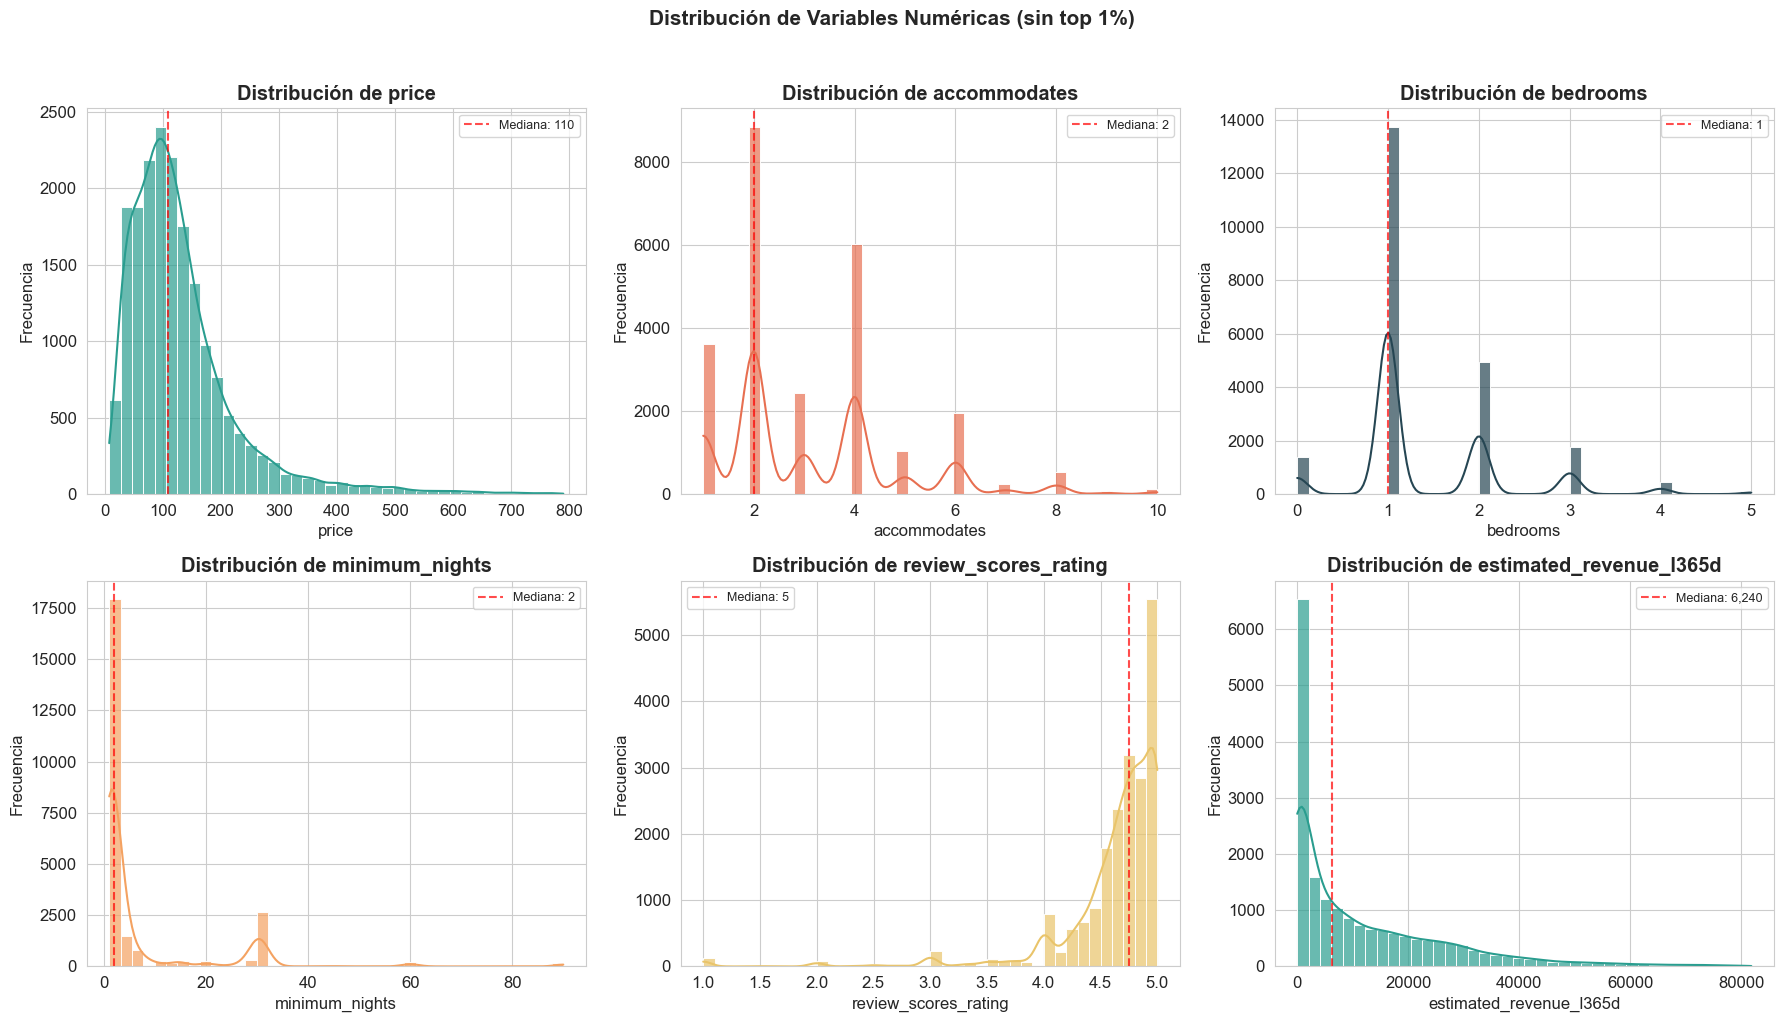


MATRIZ DE CORRELACIÓN — VARIABLES NUMÉRICAS CLAVE


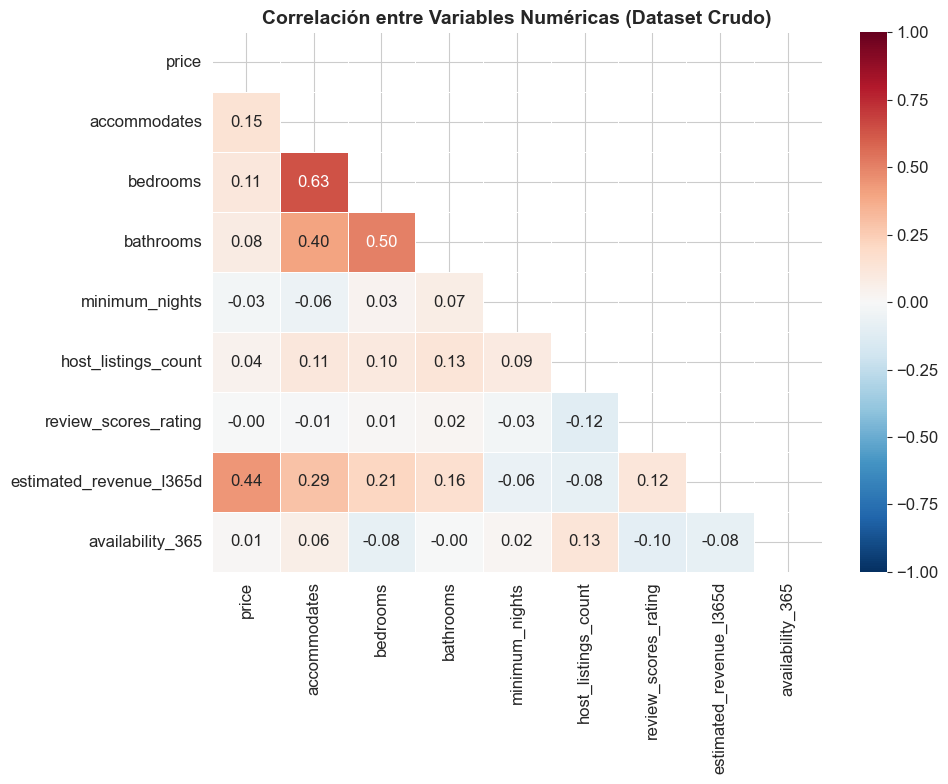

In [4]:
# ============================================================
# 1.2 DISTRIBUCIÓN DE VARIABLES NUMÉRICAS CLAVE
# ============================================================

# Histogramas con curva de densidad (KDE) para visualizar la forma de cada distribución
cols_dist = ['price', 'accommodates', 'bedrooms', 'minimum_nights',
             'review_scores_rating', 'estimated_revenue_l365d']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colores = ['#2A9D8F', '#E76F51', '#264653', '#F4A261', '#E9C46A', '#2A9D8F']

for i, col in enumerate(cols_dist):
    data = df_raw[col].dropna()
    upper = data.quantile(0.99)
    data_plot = data[data <= upper]
    sns.histplot(data_plot, kde=True, bins=40, ax=axes[i],
                 color=colores[i], edgecolor='white', alpha=0.7)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(data_plot.median(), color='red', linestyle='--', alpha=0.7,
                    label=f'Mediana: {data_plot.median():,.0f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas (sin top 1%)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Matriz de correlación del dataset en crudo ---
print("\n" + "=" * 60)
print("MATRIZ DE CORRELACIÓN — VARIABLES NUMÉRICAS CLAVE")
print("=" * 60)
cols_corr = ['price', 'accommodates', 'bedrooms', 'bathrooms',
             'minimum_nights', 'host_listings_count',
             'review_scores_rating', 'estimated_revenue_l365d',
             'availability_365']
cols_corr_exist = [c for c in cols_corr if c in df_raw.columns]

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_raw[cols_corr_exist].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlación entre Variables Numéricas (Dataset Crudo)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Preparación y Limpieza de Datos

El pipeline de limpieza sigue un orden lógico de negocio:

1. **Selección de variables:** Solo features relevantes, sin texto libre, URLs ni identificadores.
2. **Ingeniería de amenities:** Extracción de servicios clave (AC, ascensor, piscina, parking, terraza, workspace).
3. **Limpieza de tipos:** Conversión de porcentajes, variables binarias `t/f` → `1/0`.
4. **Imputación de nulos** con criterios de negocio.
5. **Filtrado de mercado real:** Solo anuncios activos (`availability_365 > 90` días).
6. **Limpieza de outliers:** Cortes con lógica de inversión inmobiliaria.

> **Data Leakage:** Se excluyen deliberadamente `number_of_reviews`, `reviews_per_month` y variables de demanda observada. Un inversor que aún no ha publicado su piso no dispone de esos datos; incluirlos inflaría la precisión del modelo artificialmente.

In [5]:

# ============================================================
# 2.1 SELECCIÓN DE VARIABLES, LIMPIEZA DE TIPOS E INGENIERÍA
# ============================================================

# --- Selección de variables relevantes (sin data leakage) ---
columnas_seleccion = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms',
    'bathrooms', 'price', 'minimum_nights', 'property_type',
    'instant_bookable', 'review_scores_rating', 'review_scores_cleanliness',
    'host_is_superhost', 'host_response_rate', 'host_listings_count',
    'amenities', 'availability_365', 'estimated_revenue_l365d'
]

df = df_raw[columnas_seleccion].copy()
print(f"Variables seleccionadas: {len(columnas_seleccion)}")
print(f"Filas iniciales: {len(df):,}")

# --- Limpieza de host_response_rate (quitar '%' → float) ---
df['host_response_rate'] = (
    df['host_response_rate'].astype(str)
    .str.replace('%', '', regex=False)
)
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')

# --- Conversión de variables binarias t/f → 1/0 ---
for col in ['host_is_superhost', 'instant_bookable']:
    df[col] = df[col].map({'t': 1, 'f': 0})

# --- Ingeniería de Variables desde Amenities ---
df['tiene_ac'] = df['amenities'].str.contains('Air conditioning|AC', case=False, na=False).astype(int)
df['tiene_ascensor'] = df['amenities'].str.contains('Elevator', case=False, na=False).astype(int)
df['tiene_piscina'] = df['amenities'].str.contains('Pool', case=False, na=False).astype(int)
df['tiene_parking'] = df['amenities'].str.contains('parking|garage', case=False, na=False).astype(int)
df['tiene_terraza'] = df['amenities'].str.contains('patio|balcony|terrace', case=False, na=False).astype(int)
df['tiene_workspace'] = df['amenities'].str.contains('workspace|desk', case=False, na=False).astype(int)

# Eliminamos la columna de texto original (ya hemos extraído lo útil)
df.drop(columns=['amenities'], inplace=True)

print(f"\n--- Ingeniería de Amenities completada ---")
print(f"Nuevas variables: tiene_ac, tiene_ascensor, tiene_piscina, tiene_parking, tiene_terraza, tiene_workspace")

# --- Imputación de valores nulos ---
print(f"\n{'='*50}")
print("VALORES NULOS ANTES DE IMPUTAR")
print(f"{'='*50}")
nulos_antes = df.isnull().sum()
print(nulos_antes[nulos_antes > 0].sort_values(ascending=False).to_string())

# Eliminamos filas sin precio ni ingresos (campos imprescindibles)
df = df.dropna(subset=['price', 'estimated_revenue_l365d'])

# Variables físicas → mediana (robusta ante outliers)
for col in ['bedrooms', 'bathrooms', 'accommodates']:
    df[col] = df[col].fillna(df[col].median())

# Puntuaciones y métricas del host → mediana
for col in ['review_scores_rating', 'review_scores_cleanliness', 'host_response_rate']:
    df[col] = df[col].fillna(df[col].median())

# Asunciones de negocio para binarias
df['host_is_superhost'] = df['host_is_superhost'].fillna(0).astype(int) # Asumimos que los nulos no son superhosts
df['instant_bookable'] = df['instant_bookable'].fillna(0).astype(int) # Asumimos que los nulos no son instant_bookable
df['host_listings_count'] = df['host_listings_count'].fillna(1) # Asumimos que los nulos tienen 1 anuncio (ellos mismos)

print(f"\nValores nulos DESPUÉS de imputar: {df.isnull().sum().sum()}") # comprueba que no quedan nulos en ninguna columna
print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Variables seleccionadas: 17
Filas iniciales: 25,000

--- Ingeniería de Amenities completada ---
Nuevas variables: tiene_ac, tiene_ascensor, tiene_piscina, tiene_parking, tiene_terraza, tiene_workspace

VALORES NULOS ANTES DE IMPUTAR
price                        6047
estimated_revenue_l365d      6047
bathrooms                    6040
review_scores_cleanliness    5148
review_scores_rating         5147
host_response_rate           4885
bedrooms                     2512
host_is_superhost             668
host_listings_count            97

Valores nulos DESPUÉS de imputar: 0
Dataset: 18,953 filas × 22 columnas


---
### 2.2 Filtrado de Mercado Real

Un piso con disponibilidad de 0 días al año no compite realmente en el mercado: puede ser un anuncio fantasma o un propietario que ha bloqueado su calendario. Para analizar solo los alojamientos con **intención real de alquiler turístico**, filtramos por `availability_365 > 90 días`.

Este corte garantiza que nuestro análisis se centra en pisos que están disponibles al menos una cuarta parte del año.

In [6]:
# ============================================================
# 2.2 FILTRADO DE MERCADO REAL
# ============================================================

FILTRO_DISPONIBILIDAD = 90  # días mínimos de disponibilidad al año

filas_antes = len(df)
df = df[df['availability_365'] > FILTRO_DISPONIBILIDAD].copy()
filas_despues = len(df)

print(f"Filtrado de mercado real (availability_365 > {FILTRO_DISPONIBILIDAD}):")
print(f"  Antes:     {filas_antes:,} anuncios")
print(f"  Después:   {filas_despues:,} anuncios")
print(f"  Eliminados: {filas_antes - filas_despues:,} ({(filas_antes - filas_despues)/filas_antes*100:.1f}%)")

Filtrado de mercado real (availability_365 > 90):
  Antes:     18,953 anuncios
  Después:   14,457 anuncios
  Eliminados: 4,496 (23.7%)


---
### 2.3 Limpieza de Outliers (Lógica de Inversión)

Eliminamos valores extremos que distorsionarían los modelos, usando cortes con sentido económico:

| Variable | Criterio | Justificación |
|---|---|---|
| `price` | Percentil 99 | Eliminar lujo extremo (áticos premium, penthouse) |
| `minimum_nights` | ≤ 31 noches | Frontera legal del alquiler turístico en España |
| `host_listings_count` | Percentil 99 | Mantener grandes gestoras (*property managers*) |
| `bedrooms` / `bathrooms` | ≤ 10 | Eliminar hostales o edificios camuflados |

In [7]:
# ============================================================
# 2.3 LIMPIEZA DE OUTLIERS
# ============================================================

filas_antes = len(df)

# 1. Price: eliminar el top 1% (lujo extremo)
corte_price = df['price'].quantile(0.99)
df = df[df['price'] <= corte_price]
print(f"[1] Corte price <= {corte_price:.0f}€          → {len(df):,} filas")

# 2. Minimum nights: máximo 31 (frontera legal turística)
df = df[df['minimum_nights'] <= 31]
print(f"[2] Corte minimum_nights <= 31      → {len(df):,} filas")

# 3. Host listings count: percentil 99 (mantener grandes gestoras)
corte_host = df['host_listings_count'].quantile(0.99)
df = df[df['host_listings_count'] <= corte_host]
print(f"[3] Corte host_listings_count <= {corte_host:.0f}  → {len(df):,} filas")

# 4. Bedrooms y bathrooms: máximo 10 (eliminar hostales camuflados)
df = df[(df['bedrooms'] <= 10) & (df['bathrooms'] <= 10)]
print(f"[4] Corte bedrooms/bathrooms <= 10  → {len(df):,} filas")

filas_despues = len(df)
print(f"\n{'='*50}")
print(f"Resumen limpieza de outliers:")
print(f"  Eliminados: {filas_antes - filas_despues:,} ({(filas_antes - filas_despues)/filas_antes*100:.1f}%)")
print(f"  Muestra limpia: {filas_despues:,} anuncios")

[1] Corte price <= 828€          → 14,312 filas
[2] Corte minimum_nights <= 31      → 13,722 filas
[3] Corte host_listings_count <= 904  → 13,661 filas
[4] Corte bedrooms/bathrooms <= 10  → 13,658 filas

Resumen limpieza de outliers:
  Eliminados: 799 (5.5%)
  Muestra limpia: 13,658 anuncios


---
## 3. Ingeniería de la Variable Objetivo: `objetivo_exito`

Definimos **éxito económico** como superar el **percentil 75** de ingresos estimados (`estimated_revenue_l365d`) de la muestra filtrada:

- **1 (Éxito):** ingresos > P75 → el piso está en el cuartil superior de facturación.
- **0 (Fracaso):** ingresos ≤ P75 → incluye los pisos con revenue = 0 (fracasos reales, la *Long Tail* del mercado).

Tras crear la variable objetivo, eliminamos `estimated_revenue_l365d` y `availability_365` para evitar **Data Leakage**: ambas contienen información directa o indirectamente vinculada al resultado que queremos predecir.

Percentil 75 de ingresos estimados: 19,454€

Distribución de la variable objetivo:
objetivo_exito
0    10243
1     3415

  Tasa de éxito: 25.0%


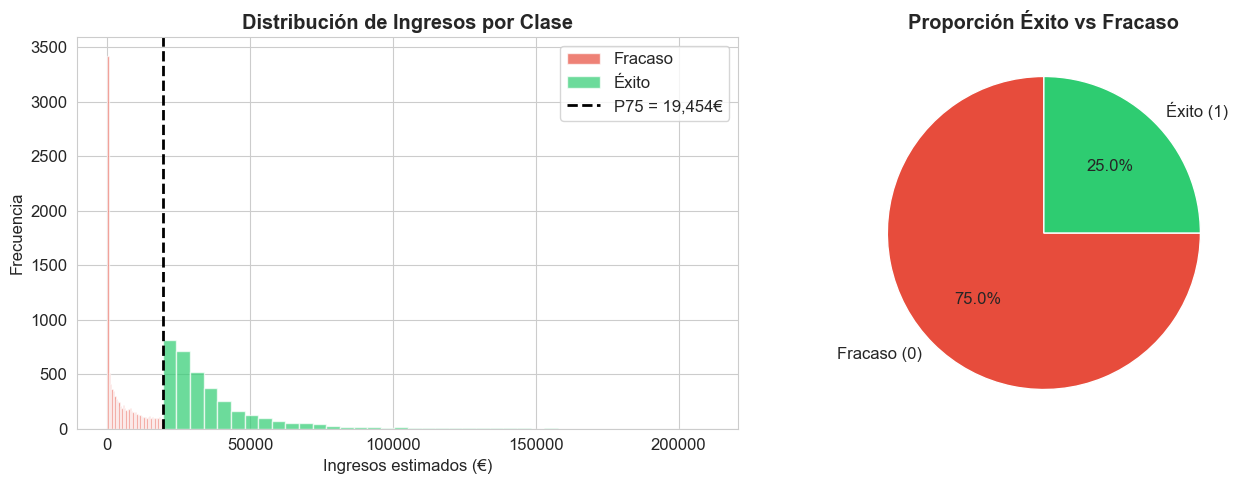


✔ Variables 'estimated_revenue_l365d' y 'availability_365' eliminadas (Data Leakage).
  Dataset final: 13,658 filas × 21 columnas


In [8]:
# ============================================================
# 3. INGENIERÍA DE LA VARIABLE OBJETIVO
# ============================================================

# Mantenemos los revenue = NaN como 0 (fracasos reales del mercado)
df['estimated_revenue_l365d'] = df['estimated_revenue_l365d'].fillna(0)# Calculamos el percentil 60 de ingresos
p75 = df['estimated_revenue_l365d'].quantile(0.75)
print(f"Percentil 75 de ingresos estimados: {p75:,.0f}€")

# Variable binaria objetivo
df['objetivo_exito'] = (df['estimated_revenue_l365d'] > p75).astype(int)

print(f"\nDistribución de la variable objetivo:")
print(df['objetivo_exito'].value_counts().to_string())
print(f"\n  Tasa de éxito: {df['objetivo_exito'].mean()*100:.1f}%")

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de ingresos por clase
for label, color, nombre in [(0, '#e74c3c', 'Fracaso'), (1, '#2ecc71', 'Éxito')]:
    subset = df[df['objetivo_exito'] == label]['estimated_revenue_l365d']
    axes[0].hist(subset, bins=40, alpha=0.7, label=nombre,
                 color=color, edgecolor='white')
axes[0].axvline(x=p75, color='black', linestyle='--', linewidth=2,
                label=f'P75 = {p75:,.0f}€')
axes[0].set_title('Distribución de Ingresos por Clase', fontweight='bold')
axes[0].set_xlabel('Ingresos estimados (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Pie chart de proporciones
df['objetivo_exito'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
    labels=['Fracaso (0)', 'Éxito (1)'], startangle=90,
    textprops={'fontsize': 12})
axes[1].set_title('Proporción Éxito vs Fracaso', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- Eliminación de variables con Data Leakage ---
df.drop(columns=['estimated_revenue_l365d', 'availability_365'], inplace=True)
print("\n✔ Variables 'estimated_revenue_l365d' y 'availability_365' eliminadas (Data Leakage).")
print(f"  Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas")

---
## 4. Análisis Exploratorio de Datos (EDA Post-Limpieza)

Con el dataset ya limpio y la variable objetivo definida, exploramos las relaciones entre las features y el éxito económico. Buscamos patrones que confirmen (o refuten) hipótesis de negocio:

- ¿Qué variables numéricas correlacionan más con el éxito?
- ¿Cómo se distribuyen las features clave según la clase (Éxito vs Fracaso)?
- ¿Influyen el tipo de habitación, el barrio o las amenities en el resultado?

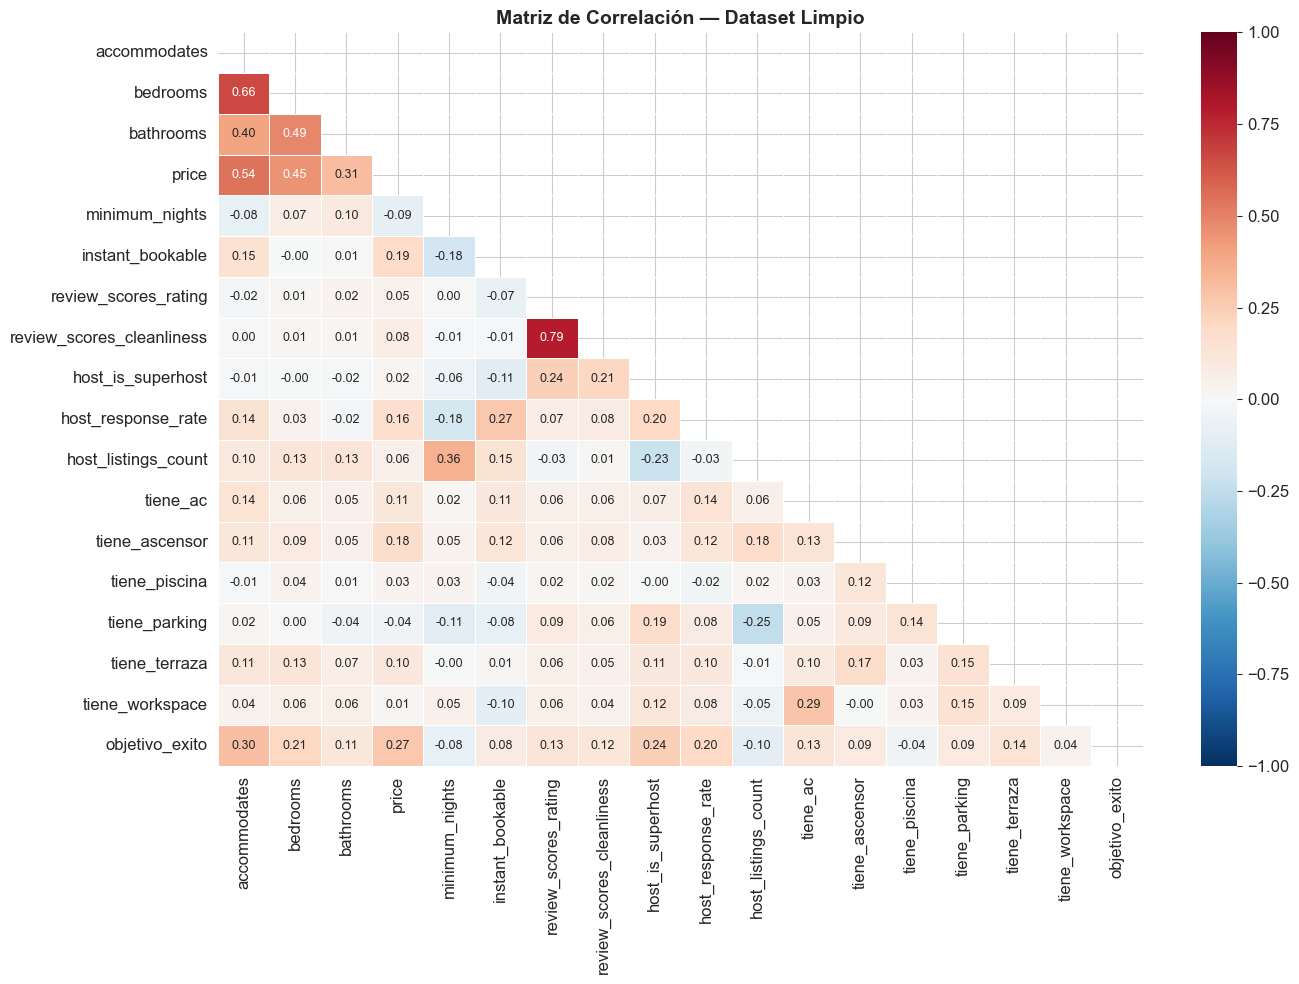

CORRELACIÓN CON objetivo_exito
  + accommodates                   +0.302  █████████
  + price                          +0.269  ████████
  + host_is_superhost              +0.237  ███████
  + bedrooms                       +0.211  ██████
  + host_response_rate             +0.198  █████
  + tiene_terraza                  +0.137  ████
  + tiene_ac                       +0.130  ███
  + review_scores_rating           +0.126  ███
  + review_scores_cleanliness      +0.119  ███
  + bathrooms                      +0.114  ███
  - host_listings_count            -0.104  ███
  + tiene_parking                  +0.092  ██
  + tiene_ascensor                 +0.092  ██
  - minimum_nights                 -0.085  ██
  + instant_bookable               +0.080  ██
  - tiene_piscina                  -0.041  █
  + tiene_workspace                +0.036  █


In [9]:
# ============================================================
# 4.1 MATRIZ DE CORRELACIÓN (DATASET LIMPIO)
# ============================================================

# Seleccionamos las variables numéricas del dataset final
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[cols_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlación — Dataset Limpio',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con la variable objetivo
print("=" * 50)
print("CORRELACIÓN CON objetivo_exito")
print("=" * 50)
corr_target = corr['objetivo_exito'].drop('objetivo_exito').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    barra = '█' * int(abs(val) * 30)
    signo = '+' if val > 0 else '-'
    print(f"  {signo} {feat:<30s} {val:+.3f}  {barra}")

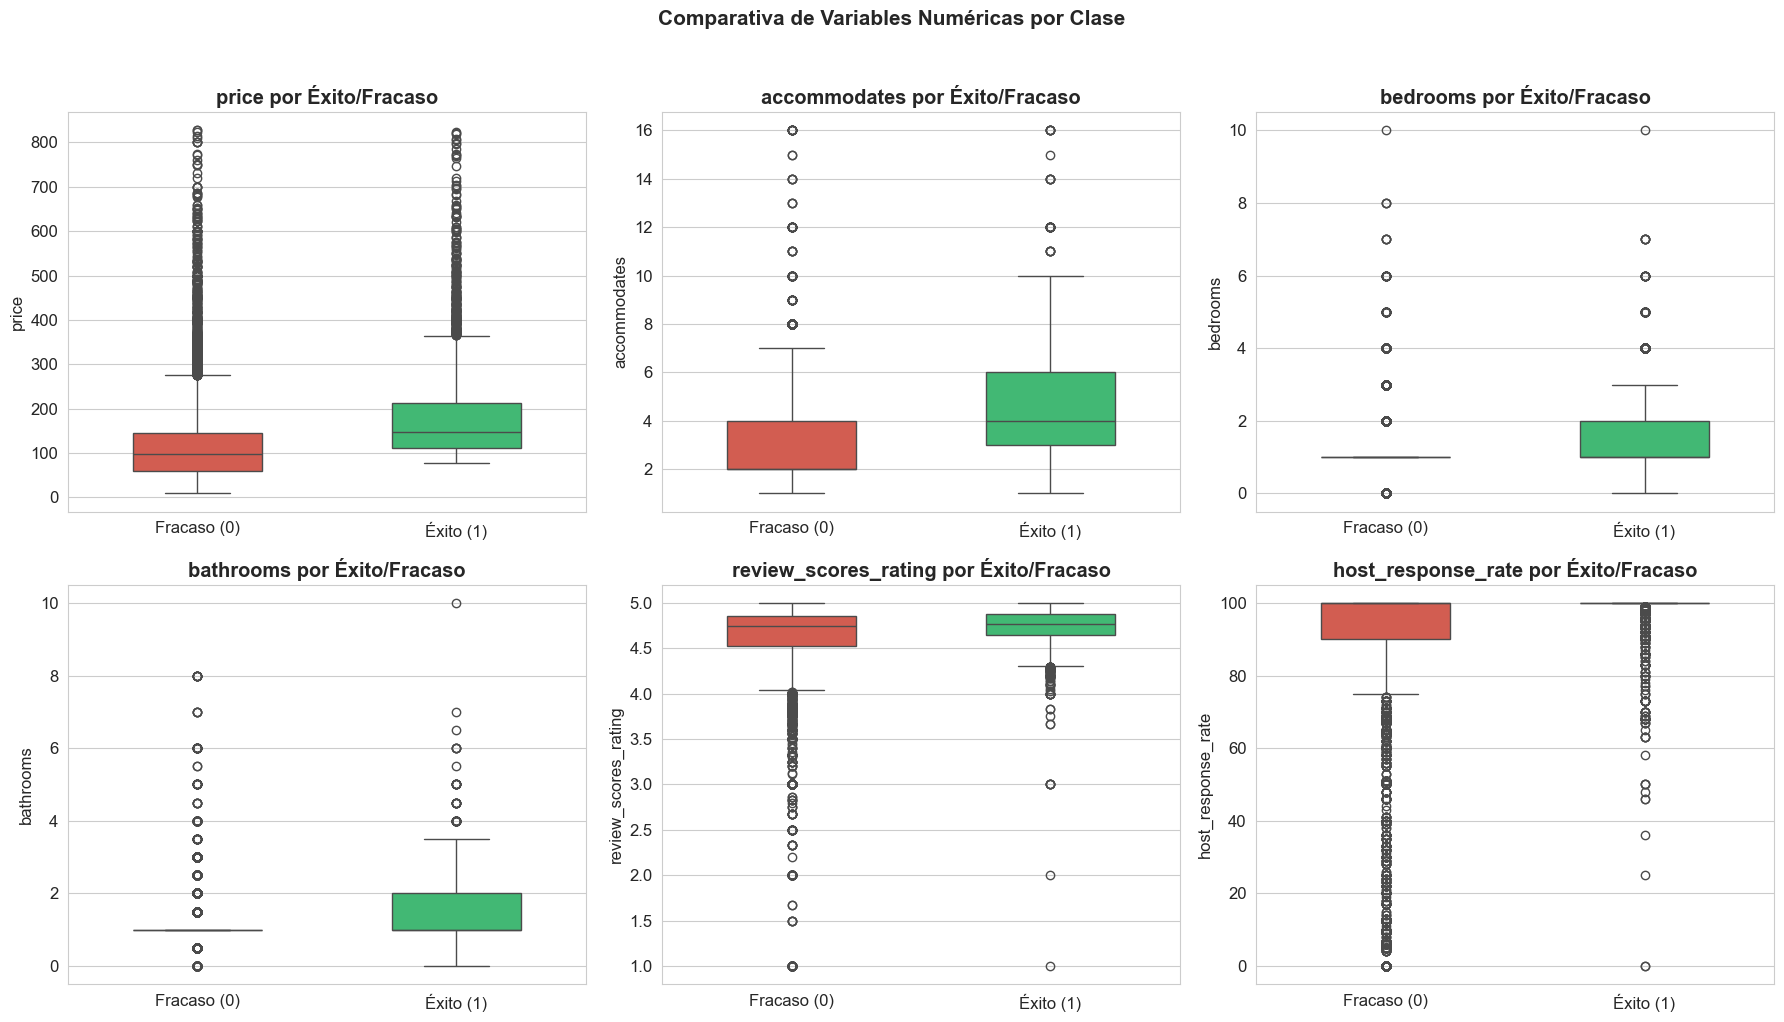

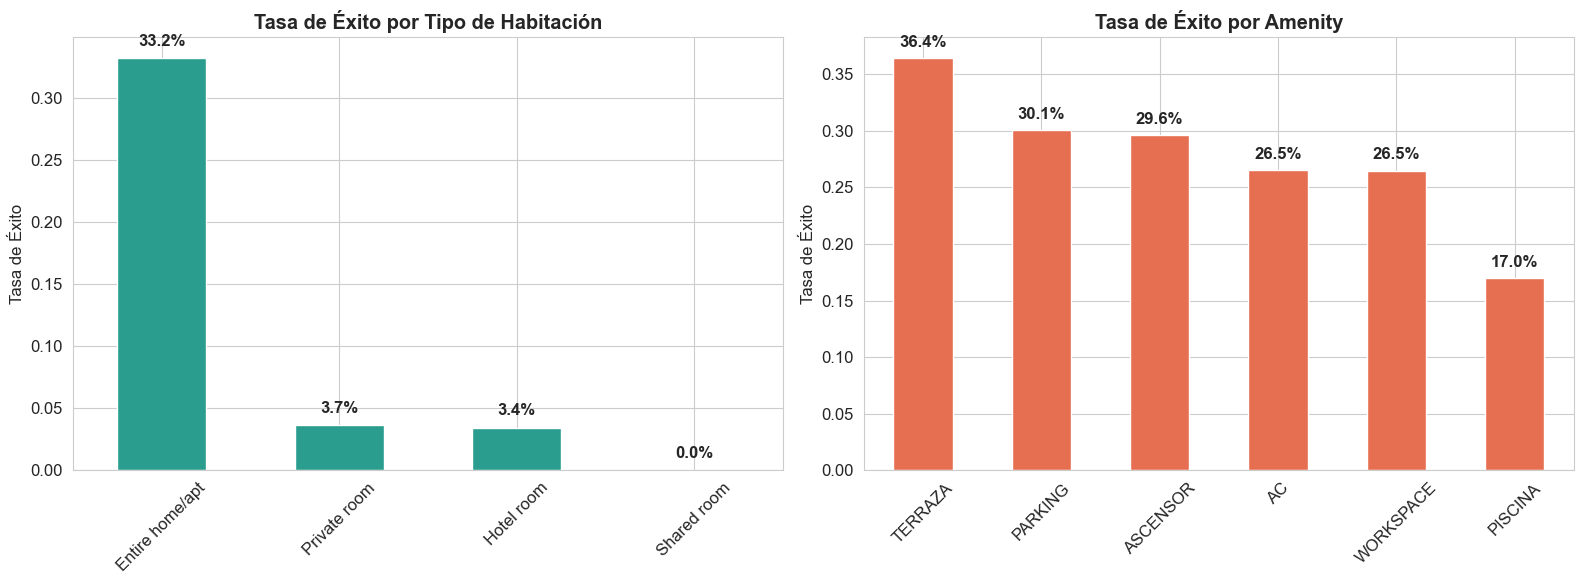

In [10]:
# ============================================================
# 4.2 DISTRIBUCIÓN DE VARIABLES CLAVE POR CLASE
# ============================================================

# --- Boxplots de variables numéricas clave por Éxito/Fracaso ---
cols_box = ['price', 'accommodates', 'bedrooms', 'bathrooms',
            'review_scores_rating', 'host_response_rate']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(data=df, x='objetivo_exito', y=col, ax=axes[i],
                palette={"0": "#e74c3c", "1": "#2ecc71"}, width=0.5)
    axes[i].set_title(f'{col} por Éxito/Fracaso', fontweight='bold')
    axes[i].set_xticklabels(['Fracaso (0)', 'Éxito (1)'])
    axes[i].set_xlabel('')

plt.suptitle('Comparativa de Variables Numéricas por Clase',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Análisis de variables categóricas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tasa de éxito por room_ty
tasa_room = df.groupby('room_type')['objetivo_exito'].mean().sort_values(ascending=False)
tasa_room.plot.bar(ax=axes[0], color='#2A9D8F', edgecolor='white')
axes[0].set_title('Tasa de Éxito por Tipo de Habitación', fontweight='bold')
axes[0].set_ylabel('Tasa de Éxito')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for j, (val, name) in enumerate(zip(tasa_room, tasa_room.index)):
    axes[0].text(j, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')

# Tasa de éxito por amenities
amenities_cols = ['tiene_ac', 'tiene_ascensor', 'tiene_piscina',
                  'tiene_parking', 'tiene_terraza', 'tiene_workspace']
tasa_amenities = pd.Series(
    {col.replace('tiene_', '').upper(): df[df[col]==1]['objetivo_exito'].mean()
     for col in amenities_cols}
).sort_values(ascending=False)
tasa_amenities.plot.bar(ax=axes[1], color='#E76F51', edgecolor='white')
axes[1].set_title('Tasa de Éxito por Amenity', fontweight='bold')
axes[1].set_ylabel('Tasa de Éxito')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for j, val in enumerate(tasa_amenities):
    axes[1].text(j, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
### 4.3 Análisis de Pricing y Eficiencia de Capacidad

Antes de entrenar cualquier modelo, necesitamos entender **cómo funciona realmente la regla de los precios en Madrid**. Dos preguntas clave:

1. **¿Cuánto se paga por huésped en cada barrio?** — Creamos la métrica `precio_por_huesped` (= `price / accommodates`) y la comparamos por barrios. Esto revela qué zonas permiten cobrar un *premium* por persona y cuáles compiten en precio puro.

2. **¿Rompe la capacidad el techo de cristal del precio?** — Representamos la relación entre capacidad y precio total. La hipótesis es que los pisos grandes no solo cobran más, sino que la **dispersión** (la horquilla de precios posibles) se amplía enormemente: un piso de 2 personas tiene un techo de ~150€, pero uno de 8 puede cobrar desde 150€ hasta 800€.

> Estos gráficos preparan el terreno para demostrar que el XGBoost es mucho más inteligente que mirar solo el precio: capta interacciones entre capacidad, barrio y gestión que un análisis univariante no puede ver.

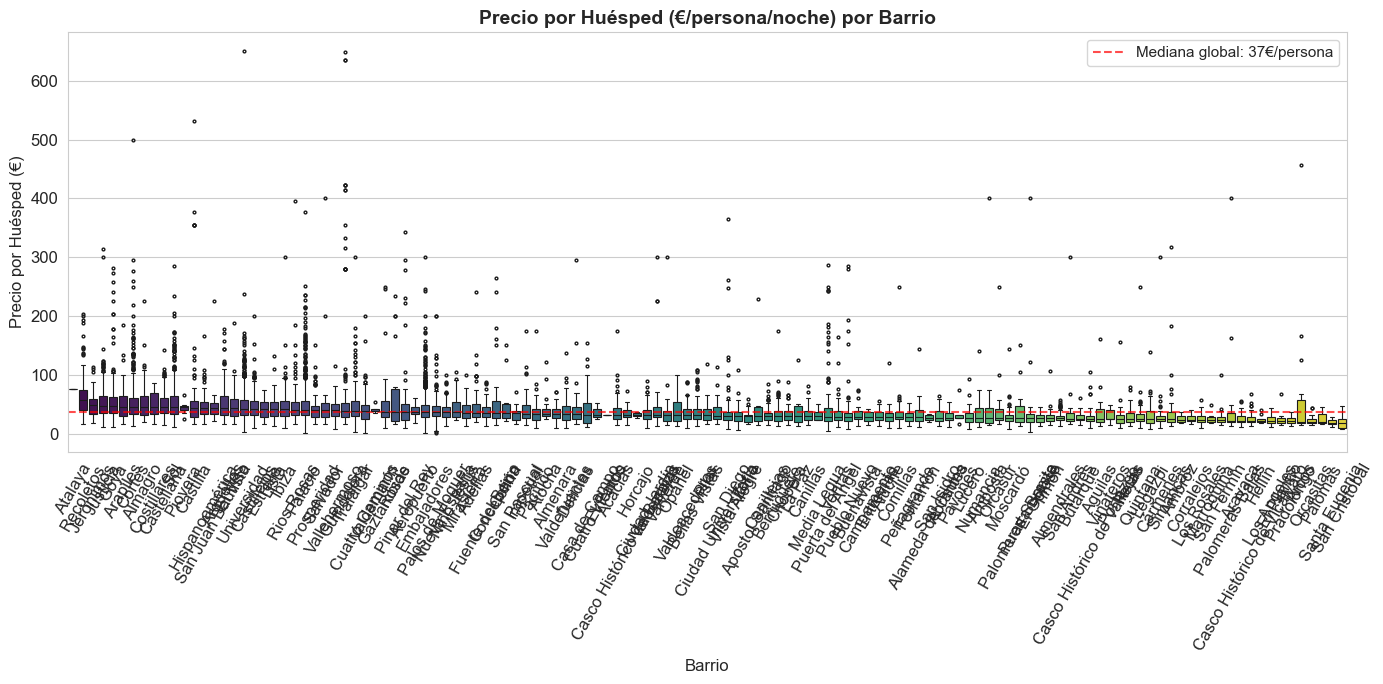

PRECIO POR HUÉSPED — RESUMEN POR BARRIO
                              Mediana (€)  Media (€)  N pisos
neighbourhood_cleansed                                       
Atalaya                              75.0       75.0        1
Recoletos                            56.2       64.2      155
Jerónimos                            49.3       50.0       65
Justicia                             47.5       51.4      636
Goya                                 46.7       57.5      209
Arapiles                             45.0       49.4      157
Cortes                               45.0       54.4      607
Almagro                              45.0       50.7      133
Costillares                          45.0       48.8       36
Castellana                           44.7       51.2      111
Sol                                  44.5       51.9      822
Piovera                              44.5       43.3       12
Castilla                             43.9       74.1       74
Hispanoamérica                

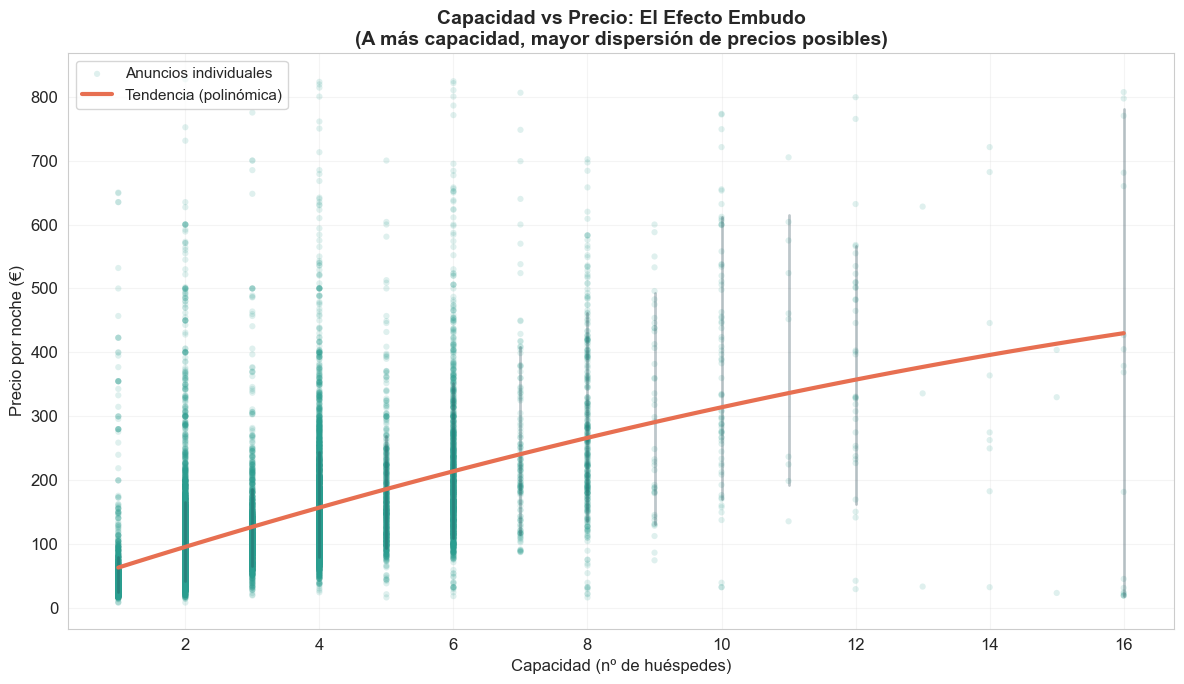


EL EFECTO EMBUDO: DISPERSIÓN DE PRECIOS POR CAPACIDAD
  1 huéspedes → P10:     25€  |  P90:     80€  |  Rango:     56€  |  n=1,506
  2 huéspedes → P10:     42€  |  P90:    166€  |  Rango:    124€  |  n=4,686
  3 huéspedes → P10:     66€  |  P90:    187€  |  Rango:    121€  |  n=1,412
  4 huéspedes → P10:     81€  |  P90:    245€  |  Rango:    164€  |  n=3,634
  5 huéspedes → P10:     95€  |  P90:    270€  |  Rango:    175€  |  n=591
  6 huéspedes → P10:    109€  |  P90:    353€  |  Rango:    244€  |  n=1,173
  7 huéspedes → P10:    115€  |  P90:    409€  |  Rango:    294€  |  n=133
  8 huéspedes → P10:    137€  |  P90:    461€  |  Rango:    324€  |  n=328
  9 huéspedes → P10:    131€  |  P90:    493€  |  Rango:    362€  |  n=43
  10 huéspedes → P10:    171€  |  P90:    611€  |  Rango:    440€  |  n=73
  11 huéspedes → P10:    193€  |  P90:    614€  |  Rango:    421€  |  n=10
  12 huéspedes → P10:    162€  |  P90:    567€  |  Rango:    404€  |  n=37
  16 huéspedes → P10:     20€  |  P9

In [11]:
# ============================================================
# 4.3 ANÁLISIS DE PRICING Y EFICIENCIA DE CAPACIDAD
# ============================================================

# --- 1. Precio por huésped por barrio ---
df['precio_por_huesped'] = df['price'] / df['accommodates']

# Ordenamos barrios por mediana de precio/huésped (descendente)
orden_barrios = (df.groupby('neighbourhood_cleansed')['precio_por_huesped']
                 .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df, x='neighbourhood_cleansed', y='precio_por_huesped',
            order=orden_barrios, palette='viridis', ax=ax,
            fliersize=2, linewidth=0.8)
ax.set_title('Precio por Huésped (€/persona/noche) por Barrio',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Barrio')
ax.set_ylabel('Precio por Huésped (€)')
ax.tick_params(axis='x', rotation=60)

# Línea de referencia: mediana global
mediana_global = df['precio_por_huesped'].median()
ax.axhline(y=mediana_global, color='red', linestyle='--', alpha=0.7, linewidth=1.5,
           label=f'Mediana global: {mediana_global:.0f}€/persona')
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Tabla resumen
print("=" * 60)
print("PRECIO POR HUÉSPED — RESUMEN POR BARRIO")
print("=" * 60)
resumen_barrio = (df.groupby('neighbourhood_cleansed')['precio_por_huesped']
                  .agg(['median', 'mean', 'count'])
                  .rename(columns={'median': 'Mediana (€)', 'mean': 'Media (€)', 'count': 'N pisos'})
                  .sort_values('Mediana (€)', ascending=False)
                  .round(1))
print(resumen_barrio.to_string())

# --- 2. Capacidad vs Precio: ¿La capacidad rompe el techo de cristal? ---
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: cada punto es un piso (con transparencia para ver la densidad)
ax.scatter(df['accommodates'], df['price'], alpha=0.15, s=20,
           color='#2A9D8F', edgecolors='none', label='Anuncios individuales')

# Línea de tendencia (regresión polinómica grado 2 para captar la curvatura)
z = np.polyfit(df['accommodates'], df['price'], 2)
p_trend = np.poly1d(z)
x_line = np.linspace(df['accommodates'].min(), df['accommodates'].max(), 100)
ax.plot(x_line, p_trend(x_line), color='#E76F51', linewidth=3,
        label='Tendencia (polinómica)', zorder=5)

# Banda de percentiles para visualizar el "embudo"
for acc in sorted(df['accommodates'].unique()):
    sub = df[df['accommodates'] == acc]['price']
    if len(sub) >= 10:
        ax.plot([acc, acc], [sub.quantile(0.10), sub.quantile(0.90)],
                color='#264653', alpha=0.3, linewidth=2)

ax.set_xlabel('Capacidad (nº de huéspedes)', fontsize=12)
ax.set_ylabel('Precio por noche (€)', fontsize=12)
ax.set_title('Capacidad vs Precio: El Efecto Embudo\n'
             '(A más capacidad, mayor dispersión de precios posibles)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Estadísticas del "embudo"
print("\n" + "=" * 60)
print("EL EFECTO EMBUDO: DISPERSIÓN DE PRECIOS POR CAPACIDAD")
print("=" * 60)
for acc in sorted(df['accommodates'].unique()):
    sub = df[df['accommodates'] == acc]['price']
    if len(sub) >= 10:
        rango = sub.quantile(0.90) - sub.quantile(0.10)
        print(f"  {int(acc)} huéspedes → P10: {sub.quantile(0.10):>6.0f}€  |  "
              f"P90: {sub.quantile(0.90):>6.0f}€  |  Rango: {rango:>6.0f}€  |  "
              f"n={len(sub):,}")

# Limpiamos la variable auxiliar (no entra en el modelo)
df.drop(columns=['precio_por_huesped'], inplace=True)
print(f"\n✔ Variable auxiliar 'precio_por_huesped' eliminada (solo análisis exploratorio).")

---
### 4.3 Segmentación del Mercado con K-Means Clustering

Para comprender la segmentación del mercado madrileño, se ha aplicado un algoritmo de **K-Means**. Este análisis revela que los inmuebles no se agrupan únicamente por barrios, sino por **«estilos de explotación»**: existe un clúster de pisos gestionados por grandes agencias profesionales frente a otro de particulares con un solo anuncio, y sus perfiles de precio, capacidad y calidad difieren notablemente.

**¿Por qué es útil?** El clustering nos permite justificar de forma visual por qué el modelo XGBoost otorga tanta importancia a `host_listings_count` y `price`. Veremos que hay un grupo de pisos que son «hermanos» porque todos pertenecen a grandes gestoras con patrones de explotación similares.

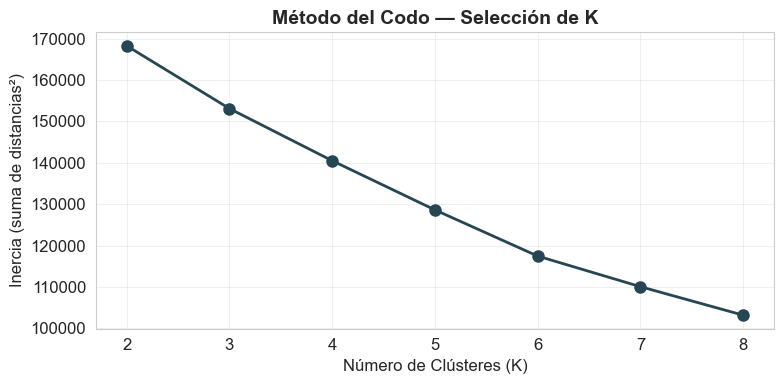

Distribución de anuncios por clúster:
cluster
0    2443
1    2801
2    7498
3     916


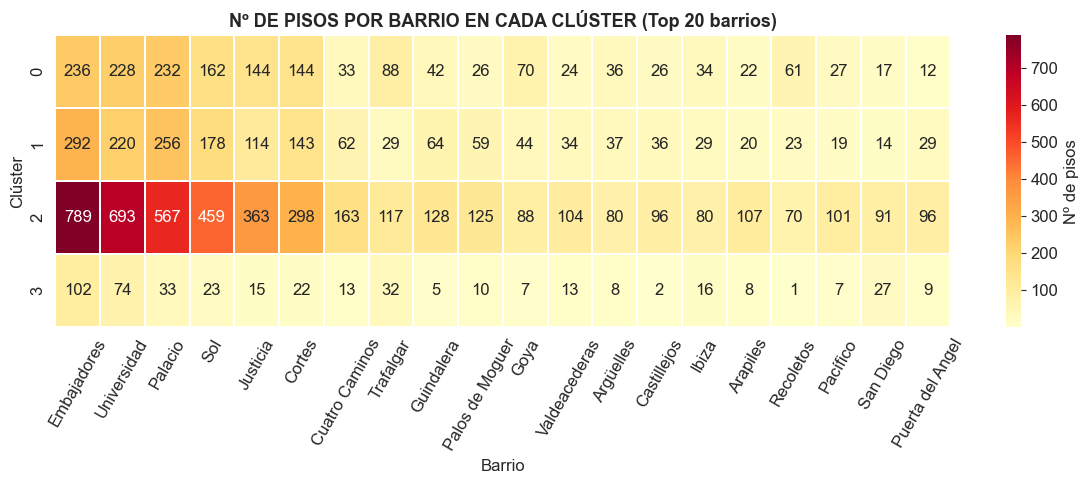


PERFIL MEDIO DE CADA CLÚSTER
cluster                           0         1         2        3
price                       250.140   118.560   109.200   90.150
accommodates                  5.890     2.910     2.760    2.290
bedrooms                      2.620     1.170     1.060    1.130
bathrooms                     2.130     1.130     1.110    1.160
minimum_nights                8.030     5.360     6.110    5.470
host_listings_count         164.980     8.660    71.300   36.020
host_response_rate           94.300    98.730    88.540   80.110
review_scores_rating          4.670     4.840     4.570    4.540
review_scores_cleanliness     4.730     4.860     4.630    4.600
host_is_superhost             0.140     1.000     0.000    0.130
instant_bookable              0.620     0.420     0.550    0.320
tiene_ac                      1.000     1.000     1.000    0.000
tiene_terraza                 0.330     0.270     0.170    0.060
tiene_workspace               0.580     0.660     0.530    0

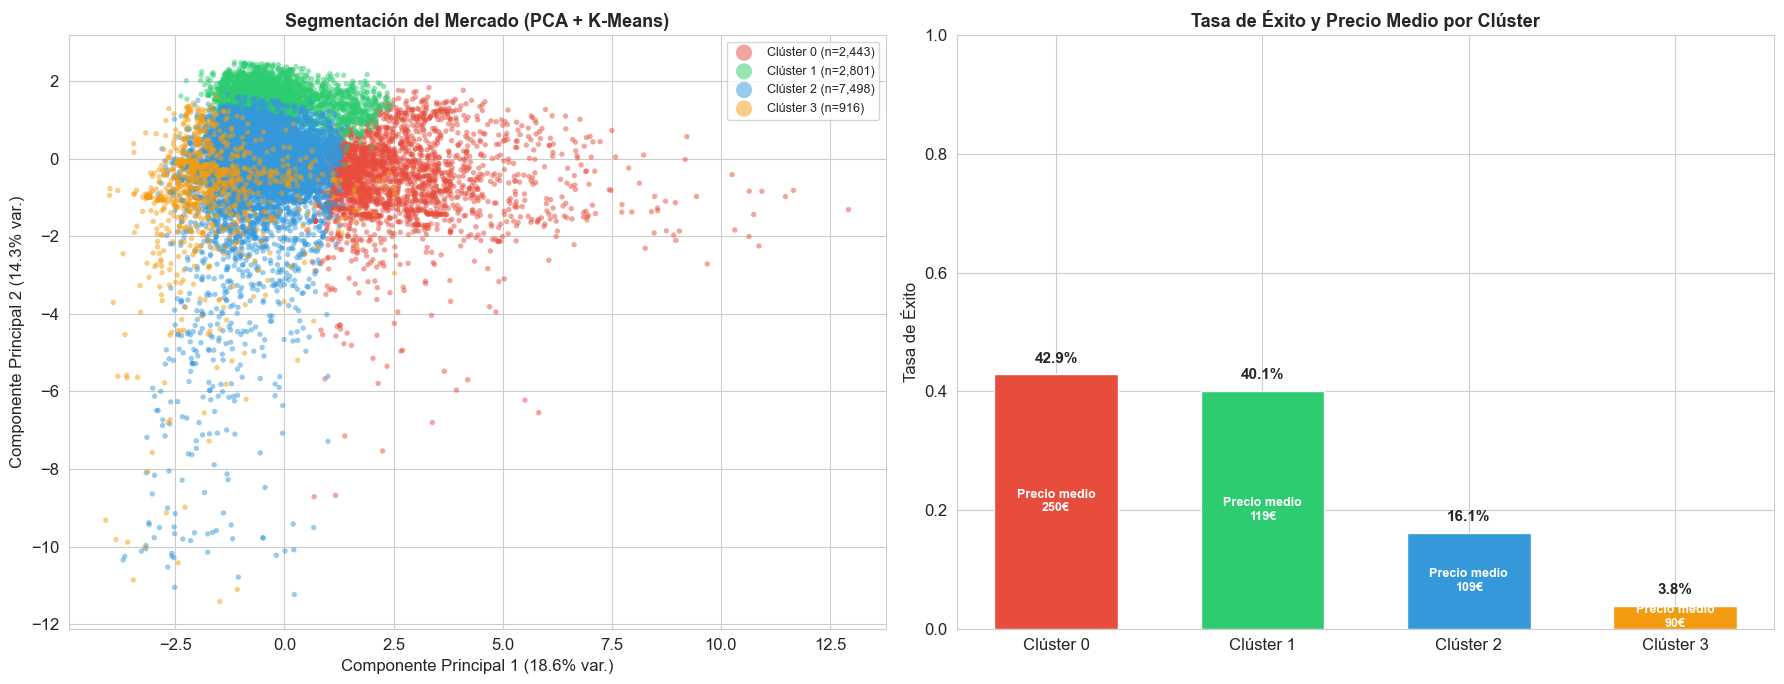

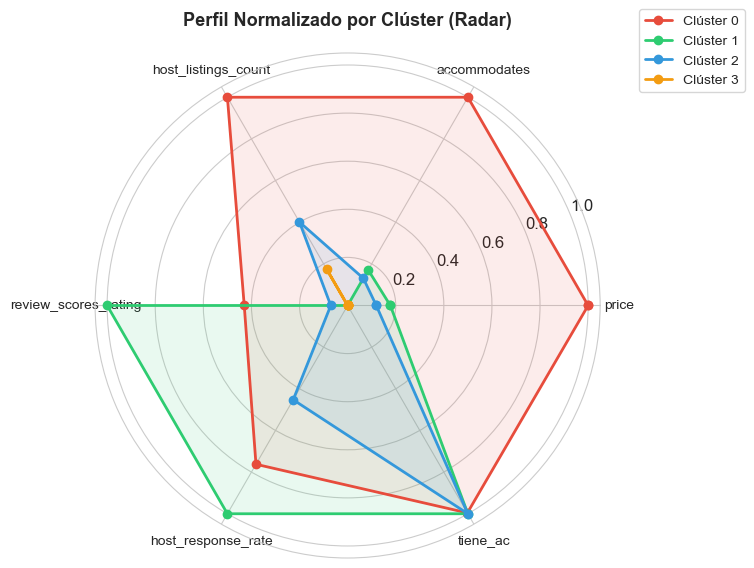


INTERPRETACIÓN DE LA SEGMENTACIÓN

  Clúster 0 (2,443 pisos, tasa éxito = 42.9%):
    Precio medio: 250€ | Capacidad: 5.9 pax | Dormitorios: 2.6
    Anuncios del host: 165.0 | Superhost: 14% | Rating: 4.67

  Clúster 1 (2,801 pisos, tasa éxito = 40.1%):
    Precio medio: 119€ | Capacidad: 2.9 pax | Dormitorios: 1.2
    Anuncios del host: 8.7 | Superhost: 100% | Rating: 4.84

  Clúster 2 (7,498 pisos, tasa éxito = 16.1%):
    Precio medio: 109€ | Capacidad: 2.8 pax | Dormitorios: 1.1
    Anuncios del host: 71.3 | Superhost: 0% | Rating: 4.57

  Clúster 3 (916 pisos, tasa éxito = 3.8%):
    Precio medio: 90€ | Capacidad: 2.3 pax | Dormitorios: 1.1
    Anuncios del host: 36.0 | Superhost: 13% | Rating: 4.54


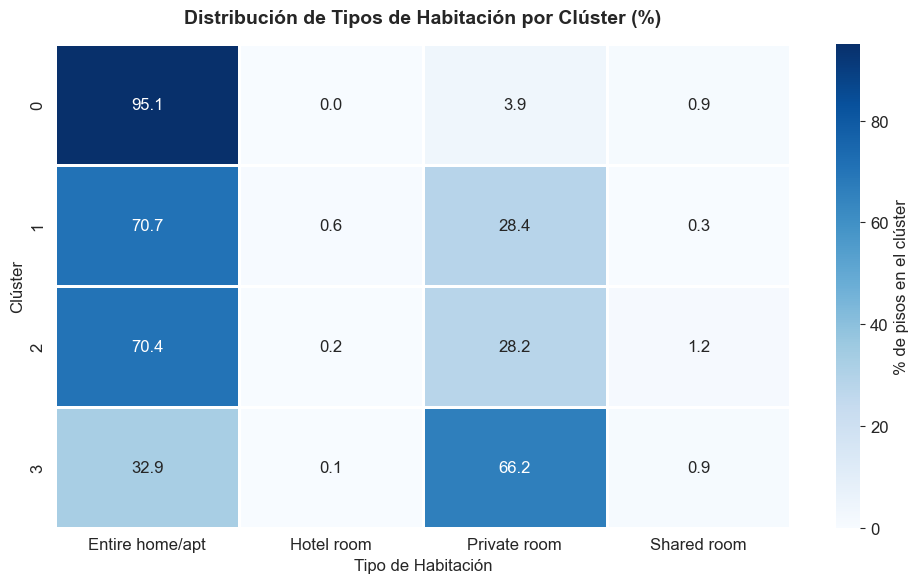


✔ Columnas 'cluster' y 'cluster_barrio' eliminadas (solo análisis exploratorio, no entran en el modelo).


'1. ¿Por qué no sale por barrios?\nEl algoritmo de clustering (K-Means) agrupa los datos por las características que más varían. En Madrid, puedes tener un piso de lujo en el barrio de Salamanca y otro igual de lujoso en Centro. Si el algoritmo los pusiera en grupos diferentes solo por el barrio, estaría ignorando que ambos funcionan igual: precio alto, mucha capacidad y gestión profesional.\n\nTu algoritmo ha decidido que en Madrid el éxito no depende de dónde estás, sino de quién eres y cómo gestionas. Ha priorizado la lógica de negocio sobre la geografía.\n\n2. La interpretación de tus 4 Clústeres (Oro puro para el Word)\nFíjate en lo que te ha dicho el modelo:\n\nClúster 0 (El "Gran Inversor/Agencia"): Es tu grupo con más éxito (42.9%). Son pisos grandes (5.9 personas), caros (250€) y de anfitriones con 165 pisos de media. Es el clúster de las grandes corporaciones.\n\nClúster 1 (El "Super-Anfitrión Boutique"): ¡Ojo aquí! Tienen un éxito brutal (40.1%) casi igual que el anterior, p

In [12]:
# ============================================================
# 4.3 SEGMENTACIÓN DEL MERCADO CON K-MEANS
# ============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- Variables numéricas para el clustering ---
cols_cluster = ['price', 'accommodates', 'bedrooms', 'bathrooms',
                'minimum_nights', 'host_listings_count', 'host_response_rate',
                'review_scores_rating', 'review_scores_cleanliness',
                'host_is_superhost', 'instant_bookable',
                'tiene_ac', 'tiene_terraza', 'tiene_workspace']

X_cluster = df[cols_cluster].copy()

# Estandarizamos para que K-Means no se sesgue por la escala
from sklearn.preprocessing import StandardScaler
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

# --- Método del Codo (Elbow) para elegir K ---
inertias = []
K_range = range(2, 9)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_cluster_scaled)
    inertias.append(km_temp.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='#264653', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clústeres (K)')
ax.set_ylabel('Inercia (suma de distancias²)')
ax.set_title('Método del Codo — Selección de K', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_range))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Entrenamiento con K=4 (codo más claro) ---
K_OPTIMO = 4
km = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_cluster_scaled)

print(f"Distribución de anuncios por clúster:")
print(df['cluster'].value_counts().sort_index().to_string())

# --- Distribución de pisos por barrio dentro de cada clúster (VISUAL) ---
from IPython.display import display
tabla_cluster_barrio = pd.crosstab(df['cluster'], df['neighbourhood_cleansed'])

# Ordenamos barrios por volumen total para mejorar la lectura
barrios_orden = tabla_cluster_barrio.sum(axis=0).sort_values(ascending=False).index
tabla_cluster_barrio = tabla_cluster_barrio[barrios_orden]

# Heatmap (Top barrios por volumen)
TOP_BARRIOS_HEATMAP = 20
tabla_heatmap = tabla_cluster_barrio.iloc[:, :TOP_BARRIOS_HEATMAP]
fig, ax = plt.subplots(figsize=(max(12, 0.6 * TOP_BARRIOS_HEATMAP), 5))
sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Nº de pisos'},
    ax=ax
)
ax.set_title(f'Nº DE PISOS POR BARRIO EN CADA CLÚSTER (Top {TOP_BARRIOS_HEATMAP} barrios)', fontsize=13, fontweight='bold')
ax.set_xlabel('Barrio')
ax.set_ylabel('Clúster')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


# --- Perfil medio de cada clúster ---
perfil = df.groupby('cluster')[cols_cluster].mean().round(2)
perfil['n_pisos'] = df['cluster'].value_counts().sort_index().values
perfil['tasa_exito'] = df.groupby('cluster')['objetivo_exito'].mean().round(3).values

print(f"\n{'='*60}")
print("PERFIL MEDIO DE CADA CLÚSTER")
print(f"{'='*60}")
print(perfil.T.to_string())

# --- Visualización 2D con PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

colores_cluster = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
nombres_cluster = {
    0: f'Clúster 0 (n={df["cluster"].value_counts()[0]:,})',
    1: f'Clúster 1 (n={df["cluster"].value_counts()[1]:,})',
    2: f'Clúster 2 (n={df["cluster"].value_counts()[2]:,})',
    3: f'Clúster 3 (n={df["cluster"].value_counts()[3]:,})',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel izquierdo: Clústeres en PCA
for cl in range(K_OPTIMO):
    mask = df['cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores_cluster[cl], label=nombres_cluster[cl],
                    alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} var.)')
axes[0].set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} var.)')
axes[0].set_title('Segmentación del Mercado (PCA + K-Means)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, markerscale=3)

# Panel derecho: Tasa de éxito y precio medio por clúster
tasa_cluster = df.groupby('cluster')['objetivo_exito'].mean()
precio_cluster = df.groupby('cluster')['price'].mean()

x_pos = np.arange(K_OPTIMO)
bars = axes[1].bar(x_pos, tasa_cluster, color=colores_cluster, edgecolor='white', width=0.6)

# Anotamos tasa de éxito y precio medio
for i, (tasa, precio) in enumerate(zip(tasa_cluster, precio_cluster)):
    axes[1].text(i, tasa + 0.02, f'{tasa:.1%}', ha='center', fontweight='bold', fontsize=11)
    axes[1].text(i, tasa / 2, f'Precio medio\n{precio:.0f}€', ha='center',
                 va='center', fontsize=9, color='white', fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Clúster {i}' for i in range(K_OPTIMO)])
axes[1].set_ylabel('Tasa de Éxito')
axes[1].set_title('Tasa de Éxito y Precio Medio por Clúster', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# --- Radar chart: Perfil normalizado de cada clúster ---
cols_radar = ['price', 'accommodates', 'host_listings_count',
              'review_scores_rating', 'host_response_rate', 'tiene_ac']

perfil_norm = df.groupby('cluster')[cols_radar].mean()
# Normalizamos cada variable entre 0 y 1 para comparar en la misma escala
for col in cols_radar:
    rango = perfil_norm[col].max() - perfil_norm[col].min()
    if rango > 0:
        perfil_norm[col] = (perfil_norm[col] - perfil_norm[col].min()) / rango

angles = np.linspace(0, 2 * np.pi, len(cols_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cl in range(K_OPTIMO):
    values = perfil_norm.loc[cl].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Clúster {cl}',
            color=colores_cluster[cl])
    ax.fill(angles, values, alpha=0.1, color=colores_cluster[cl])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cols_radar, fontsize=10)
ax.set_title('Perfil Normalizado por Clúster (Radar)', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

# --- Interpretación automática ---
print("\n" + "=" * 60)
print("INTERPRETACIÓN DE LA SEGMENTACIÓN")
print("=" * 60)
for cl in range(K_OPTIMO):
    p = perfil.loc[cl]
    tasa = df[df['cluster'] == cl]['objetivo_exito'].mean()
    print(f"\n  Clúster {cl} ({int(p['n_pisos']):,} pisos, tasa éxito = {tasa:.1%}):")
    print(f"    Precio medio: {p['price']:.0f}€ | Capacidad: {p['accommodates']:.1f} pax | "
          f"Dormitorios: {p['bedrooms']:.1f}")
    print(f"    Anuncios del host: {p['host_listings_count']:.1f} | "
          f"Superhost: {p['host_is_superhost']:.0%} | Rating: {p['review_scores_rating']:.2f}")

# ------------------------------------------------------------
# 4.3-bis CLUSTER POR BARRIO (meta-clustering de barrios)
# ------------------------------------------------------------
# Aquí no clusterizamos anuncios individuales, sino barrios según su perfil medio.
perfil_barrio = (
    df.groupby('neighbourhood_cleansed')
      .agg(
          price_medio=('price', 'mean'),
          capacidad_media=('accommodates', 'mean'),
          host_listings_medio=('host_listings_count', 'mean'),
          rating_medio=('review_scores_rating', 'mean'),
          response_rate_media=('host_response_rate', 'mean'),
          tasa_exito=('objetivo_exito', 'mean'),
          n_anuncios=('objetivo_exito', 'size')
      )
      .reset_index()
)

if perfil_barrio.shape[0] >= 2:
    K_BARRIO = min(4, perfil_barrio.shape[0])

    cols_cluster_barrio = [
        'price_medio', 'capacidad_media', 'host_listings_medio',
        'rating_medio', 'response_rate_media', 'tasa_exito'
    ]

    scaler_barrio = StandardScaler()
    X_barrio_scaled = scaler_barrio.fit_transform(perfil_barrio[cols_cluster_barrio])

    km_barrio = KMeans(n_clusters=K_BARRIO, random_state=42, n_init=10)
    perfil_barrio['cluster_barrio'] = km_barrio.fit_predict(X_barrio_scaled)

# 1. Calculamos los porcentajes (Crosstab normalizado por las filas del clúster)
crosstab_porcentaje = pd.crosstab(df['cluster'], df['room_type'], normalize='index') * 100

# 2. Configuramos el tamaño del gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Creamos el mapa de calor con Seaborn
sns.heatmap(crosstab_porcentaje, 
            annot=True,          # Muestra el número exacto dentro de la celda
            fmt=".1f",           # Formato con 1 decimal (ej: 95.2)
            cmap="Blues",        # Paleta de colores (tonos azules, muy profesional)
            cbar_kws={'label': '% de pisos en el clúster'},
            linewidths=1,        # Líneas de separación entre celdas
            ax=ax)

# 4. Títulos y etiquetas de estilo académico
ax.set_title('Distribución de Tipos de Habitación por Clúster (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tipo de Habitación', fontsize=12)
ax.set_ylabel('Clúster', fontsize=12)
plt.tight_layout()
plt.show()



# Eliminamos las columnas de cluster (solo análisis exploratorio, no entran en el modelado)
df.drop(columns=['cluster', 'cluster_barrio'], inplace=True, errors='ignore')
print(f"\n✔ Columnas 'cluster' y 'cluster_barrio' eliminadas (solo análisis exploratorio, no entran en el modelo).")

"""1. ¿Por qué no sale por barrios?
El algoritmo de clustering (K-Means) agrupa los datos por las características que más varían. En Madrid, puedes tener un piso de lujo en el barrio de Salamanca y otro igual de lujoso en Centro. Si el algoritmo los pusiera en grupos diferentes solo por el barrio, estaría ignorando que ambos funcionan igual: precio alto, mucha capacidad y gestión profesional.

Tu algoritmo ha decidido que en Madrid el éxito no depende de dónde estás, sino de quién eres y cómo gestionas. Ha priorizado la lógica de negocio sobre la geografía.

2. La interpretación de tus 4 Clústeres (Oro puro para el Word)
Fíjate en lo que te ha dicho el modelo:

Clúster 0 (El "Gran Inversor/Agencia"): Es tu grupo con más éxito (42.9%). Son pisos grandes (5.9 personas), caros (250€) y de anfitriones con 165 pisos de media. Es el clúster de las grandes corporaciones.

Clúster 1 (El "Super-Anfitrión Boutique"): ¡Ojo aquí! Tienen un éxito brutal (40.1%) casi igual que el anterior, pero con solo 8 pisos de media. ¿Su secreto? Son 100% Superhosts y tienen el mejor rating (4.84). Este es el modelo de éxito para un pequeño inversor.

Clúster 2 (El "Gestor Medio/Novato"): Muchos pisos (7.498), pero poca tasa de éxito (16.1%). Aquí está la masa del mercado que no termina de despuntar.

Clúster 3 (El "Low Cost/Habitaciones"): Éxito casi nulo (3.8%). Precios bajos y pocas comodidades.

3. ¿El algoritmo de predicción (XGBoost) lo hace automáticamente?
Sí, exactamente. Cuando metes las variables de barrio (las columnas neighbourhood_cleansed_...) en el XGBoost:

El XGBoost mira si estar en "Sol" ayuda a predecir el éxito.

Si descubre que un piso en Sol con mala gestión fracasa, y un piso en un barrio más humilde con gestión profesional triunfa, le dará más importancia a la gestión que al barrio.

Como viste en tu Top 15 de importancia, los barrios aparecían muy abajo. Esto confirma tu clustering: el modelo de explotación mata al código postal.

💡 Cómo meter esto en el Word para que quede "pro"
No digas "no sale por barrios". Tienes que venderlo así:

"Se realizó un análisis de segmentación (K-Means) para identificar los perfiles estratégicos del mercado. Los resultados demuestran que el mercado de Airbnb en Madrid está segmentado por niveles de profesionalización y capacidad del activo, y no por una distribución geográfica simple. Esto sugiere que un activo bien gestionado y con alta capacidad puede ser exitoso independientemente del barrio, validando la tesis de que la gestión operativa es el factor diferencial de rentabilidad."""

In [13]:
# Rescatamos las coordenadas del dataset original y se las pegamos al limpio
df['latitude'] = df_raw['latitude']
df['longitude'] = df_raw['longitude']

# Y ahora creamos el mapa de calor
import folium
from folium.plugins import HeatMap

mapa_madrid = folium.Map(location=[40.4168, -3.7038], zoom_start=12)
pisos_exito = df[df['objetivo_exito'] == 1][['latitude', 'longitude']].dropna()
HeatMap(pisos_exito.values.tolist(), radius=10, blur=15).add_to(mapa_madrid)

mapa_madrid.save('mapa_calor_exito.html')
mapa_madrid

---
## 5. Preparación para Modelado y Entrenamiento

### 5.1 Preparación de variables categóricas

Antes de entrenar, necesitamos:
- **Agrupar categorías minoritarias** en `property_type` (< 1%) y `neighbourhood_cleansed` (< 0.5%) para reducir la dimensionalidad sin perder información relevante.
- Aplicar **One-Hot Encoding** a las variables categóricas restantes (`property_type`, `room_type`, `neighbourhood_cleansed`).
- Dividir en **Train (80%) / Test (20%)** con estratificación.
- Aplicar **StandardScaler** solo para la Regresión Logística (los modelos basados en árboles no lo requieren).

### 5.2 Modelos a entrenar

| Modelo | Tipo | Justificación |
|---|---|---|
| **Regresión Logística** | Lineal | Baseline interpretable, referencia mínima |
| **Random Forest** | Ensemble (Bagging) | Captura no linealidades, robusto ante ruido |
| **XGBoost** | Ensemble (Boosting) | Estado del arte en datos tabulares |

In [14]:
# ============================================================
# 5.1 FEATURE ENGINEERING ESPACIAL + ONE-HOT ENCODING + SPLIT
# ============================================================

# --- Dependencia para distancia geodésica (robusto) ---
try:
    from geopy.distance import geodesic
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'geopy'])
    from geopy.distance import geodesic

# --- Función robusta para rescatar coordenadas ---
def rescatar_coordenadas(df_local, df_raw_local):
    """
    Garantiza columnas latitude/longitude en df_local.
    Prioriza unión por 'id' si existe en ambos dataframes.
    Si no existe 'id', usa alineación por índice para mantener integridad.
    """
    df_local = df_local.copy()

    lat_candidatas = ['latitude', 'latitud']
    lon_candidatas = ['longitude', 'longitud']

    col_lat_raw = next((c for c in lat_candidatas if c in df_raw_local.columns), None)
    col_lon_raw = next((c for c in lon_candidatas if c in df_raw_local.columns), None)

    if col_lat_raw is None or col_lon_raw is None:
        raise ValueError("No se encontraron coordenadas en df_raw (latitude/longitude).")

    # Normalizamos nombres en df_local
    if 'latitude' not in df_local.columns:
        if 'latitud' in df_local.columns:
            df_local['latitude'] = df_local['latitud']
        else:
            df_local['latitude'] = np.nan

    if 'longitude' not in df_local.columns:
        if 'longitud' in df_local.columns:
            df_local['longitude'] = df_local['longitud']
        else:
            df_local['longitude'] = np.nan

    # Si faltan coordenadas, intentamos rescatarlas
    faltan_lat = df_local['latitude'].isna()
    faltan_lon = df_local['longitude'].isna()

    if (faltan_lat.any() or faltan_lon.any()) and ('id' in df_local.columns) and ('id' in df_raw_local.columns):
        coords_por_id = (
            df_raw_local[['id', col_lat_raw, col_lon_raw]]
            .dropna(subset=[col_lat_raw, col_lon_raw])
            .drop_duplicates(subset='id', keep='first')
            .set_index('id')
        )
        df_local.loc[faltan_lat, 'latitude'] = df_local.loc[faltan_lat, 'id'].map(coords_por_id[col_lat_raw])
        df_local.loc[faltan_lon, 'longitude'] = df_local.loc[faltan_lon, 'id'].map(coords_por_id[col_lon_raw])
        print("Coordenadas recuperadas con unión por 'id'.")
    elif faltan_lat.any() or faltan_lon.any():
        coords_idx = df_raw_local[[col_lat_raw, col_lon_raw]].reindex(df_local.index)
        df_local.loc[faltan_lat, 'latitude'] = coords_idx.loc[faltan_lat, col_lat_raw]
        df_local.loc[faltan_lon, 'longitude'] = coords_idx.loc[faltan_lon, col_lon_raw]
        print("Coordenadas recuperadas por alineación de índice.")
    else:
        print("Las coordenadas ya estaban completas en df.")

    return df_local


# --- 1) Recuperar coordenadas ---
df = rescatar_coordenadas(df, df_raw)

# Conversión robusta a numérico
for col in ['latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminamos solo filas sin coordenadas válidas
filas_antes_coord = len(df)
df = df.dropna(subset=['latitude', 'longitude']).copy()
filas_despues_coord = len(df)
if filas_despues_coord < filas_antes_coord:
    print(f"Filas eliminadas por coordenadas faltantes: {filas_antes_coord - filas_despues_coord}")

# --- 2) Feature espacial: distancia al centro de Madrid (Puerta del Sol) ---
CENTRO_MADRID = (40.4168, -3.7038)

df['distancia_centro_km'] = df.apply(
    lambda row: geodesic((row['latitude'], row['longitude']), CENTRO_MADRID).km,
    axis=1
)

print("\nResumen de distancia_centro_km:")
print(df['distancia_centro_km'].describe().round(3).to_string())

# --- 3) Agrupar property_type minoritarios (< 1%) ---
freq_prop = df['property_type'].value_counts(normalize=True)
tipos_raros = freq_prop[freq_prop < 0.01].index
df['property_type'] = df['property_type'].where(
    ~df['property_type'].isin(tipos_raros), 'Otros Tipos'
)
print(f"\nproperty_type: {df['property_type'].nunique()} categorías (agrupadas < 1%)")

# --- 4) Agrupar neighbourhood_cleansed minoritarios (< 0.5%) ---
freq_barrio = df['neighbourhood_cleansed'].value_counts(normalize=True)
barrios_raros = freq_barrio[freq_barrio < 0.005].index
df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].where(
    ~df['neighbourhood_cleansed'].isin(barrios_raros), 'Otros Barrios'
)
print(f"neighbourhood_cleansed: {df['neighbourhood_cleansed'].nunique()} categorías (agrupadas < 0.5%)")

# --- 5) One-Hot Encoding ---
cols_cat = ['property_type', 'room_type', 'neighbourhood_cleansed']
df_model = pd.get_dummies(df, columns=cols_cat, drop_first=True, dtype=int)

print(f"\nDataset tras One-Hot Encoding: {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas")


# --- 6) Separar Features (X) y Target (y) ---
# IMPORTANTE: incluimos distancia_centro_km y excluimos lat/lon crudas
cols_excluir_modelo = ['objetivo_exito', 'latitude', 'longitude', 'latitud', 'longitud', 'id']
X = df_model.drop(columns=cols_excluir_modelo, errors='ignore')
y = df_model['objetivo_exito']

if 'distancia_centro_km' not in X.columns:
    raise ValueError("distancia_centro_km no está en X. Revisa el pipeline de creación de features.")

print(f"\nFeatures: {X.shape[1]}")
print(f"'distancia_centro_km' en X: {'distancia_centro_km' in X.columns}")
print(f"Latitude/Longitude excluidas: {all(c not in X.columns for c in ['latitude', 'longitude', 'latitud', 'longitud'])}")
print(f"Target:\n{y.value_counts().to_string()}")

# --- 7) División Train/Test (80/20) estratificada ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# --- 8) StandardScaler (solo para Regresión Logística) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Las coordenadas ya estaban completas en df.

Resumen de distancia_centro_km:
count    13658.000
mean         2.699
std          2.447
min          0.006
25%          0.775
50%          1.899
75%          4.024
max         14.489

property_type: 9 categorías (agrupadas < 1%)
neighbourhood_cleansed: 51 categorías (agrupadas < 0.5%)

Dataset tras One-Hot Encoding: 13,658 filas × 82 columnas

Features: 79
'distancia_centro_km' en X: True
Latitude/Longitude excluidas: True
Target:
objetivo_exito
0    10243
1     3415

Train: 10,926 filas | Test: 2,732 filas


In [15]:
# ============================================================
# 5.2 MODELO 1: REGRESIÓN LOGÍSTICA (BASELINE)
# ============================================================

from sklearn.metrics import roc_auc_score


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("=" * 50)
print("REGRESIÓN LOGÍSTICA (Baseline)")
print("=" * 50)
print(f"  Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"  Recall:   {recall_lr:.4f}")
print(f"  AUC:      {auc_lr:.4f}")
print(f"  F1-Score: {f1_lr:.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['Fracaso', 'Éxito'])}")

REGRESIÓN LOGÍSTICA (Baseline)
  Accuracy: 0.7910 (79.10%)
  Recall:   0.4597
  AUC:      0.8339
  F1-Score: 0.5238

              precision    recall  f1-score   support

     Fracaso       0.83      0.90      0.87      2049
       Éxito       0.61      0.46      0.52       683

    accuracy                           0.79      2732
   macro avg       0.72      0.68      0.69      2732
weighted avg       0.78      0.79      0.78      2732



In [16]:
# ============================================================
# 5.3 MODELO 2: RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"  Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"  Recall:   {recall_rf:.4f}")
print(f"  AUC:      {auc_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Fracaso', 'Éxito'])}")

RANDOM FOREST
  Accuracy: 0.8525 (85.25%)
  Recall:   0.6047
  AUC:      0.9205
  F1-Score: 0.6721

              precision    recall  f1-score   support

     Fracaso       0.88      0.94      0.90      2049
       Éxito       0.76      0.60      0.67       683

    accuracy                           0.85      2732
   macro avg       0.82      0.77      0.79      2732
weighted avg       0.85      0.85      0.85      2732



In [17]:
# ============================================================
# 5.4 MODELO 3: XGBOOST
# ============================================================

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False,
    eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("=" * 50)
print("XGBOOST")
print("=" * 50)
print(f"  Accuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")
print(f"  Recall:   {recall_xgb:.4f}")
print(f"  AUC:      {auc_xgb:.4f}")
print(f"  F1-Score: {f1_xgb:.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Fracaso', 'Éxito'])}")

XGBOOST
  Accuracy: 0.8682 (86.82%)
  Recall:   0.7540
  AUC:      0.9361
  F1-Score: 0.7410

              precision    recall  f1-score   support

     Fracaso       0.92      0.91      0.91      2049
       Éxito       0.73      0.75      0.74       683

    accuracy                           0.87      2732
   macro avg       0.82      0.83      0.83      2732
weighted avg       0.87      0.87      0.87      2732



COMPARATIVA DE MODELOS
             Modelo Accuracy Recall    AUC F1-Score Precision
            XGBoost   0.8682 0.7540 0.9361   0.7410    0.7284
      Random Forest   0.8525 0.6047 0.9205   0.6721    0.7564
Regresión Logística   0.7910 0.4597 0.8339   0.5238    0.6085


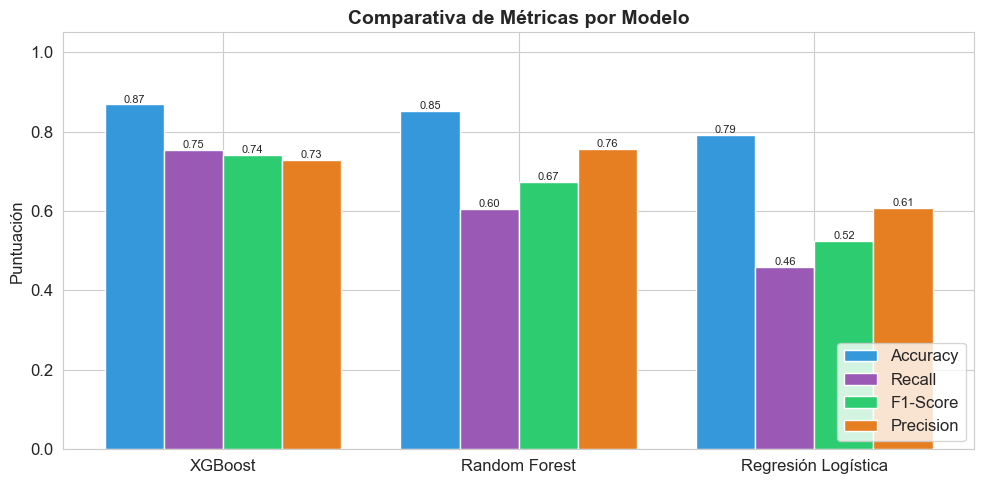

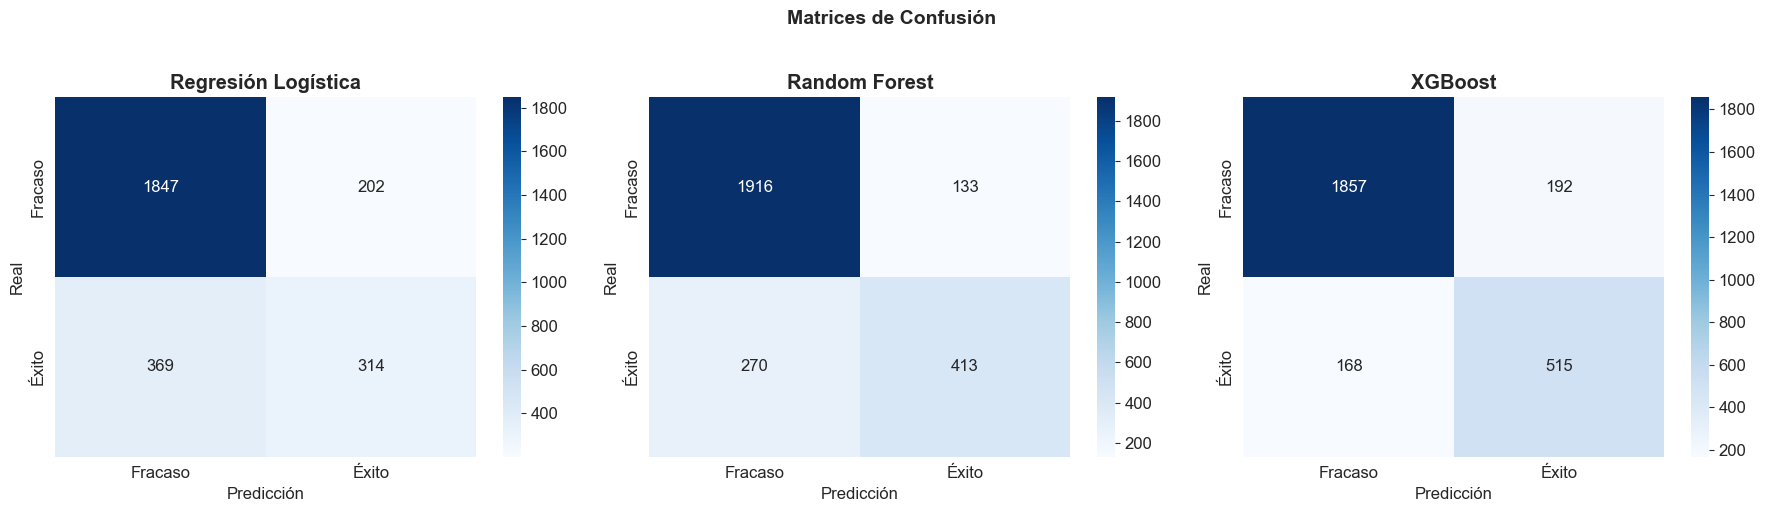

In [18]:
# ============================================================
# 6.1 COMPARATIVA DE MODELOS + MATRICES DE CONFUSIÓN
# ============================================================

# --- Tabla comparativa ---
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb],
    'Recall': [recall_lr, recall_rf, recall_xgb],
    'AUC': [auc_lr, auc_rf, auc_xgb],
    'F1-Score': [f1_lr, f1_rf, f1_xgb],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("=" * 70)
print("COMPARATIVA DE MODELOS")
print("=" * 70)
print(resultados.to_string(index=False, formatters={
    'Accuracy': '{:.4f}'.format,
    'Recall': '{:.4f}'.format,
    'AUC': '{:.4f}'.format,
    'F1-Score': '{:.4f}'.format,
    'Precision': '{:.4f}'.format
}))

# --- Gráfico comparativo de métricas ---
# IMPORTANTE: en barras solo mostramos Accuracy, Recall, F1 y Precision
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(resultados))
w = 0.2

metrics = ['Accuracy', 'Recall', 'F1-Score', 'Precision']
colors = ['#3498db', '#9b59b6', '#2ecc71', '#e67e22']

for i, (met, col) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*w, resultados[met], width=w, label=met, color=col, edgecolor='white')
    for j, val in enumerate(resultados[met]):
        ax.text(x[j] + i*w, val + 0.005, f'{val:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(resultados['Modelo'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Matrices de Confusión ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre, y_pred in zip(axes,
    ['Regresión Logística', 'Random Forest', 'XGBoost'],
    [y_pred_lr, y_pred_rf, y_pred_xgb]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fracaso', 'Éxito'],
                yticklabels=['Fracaso', 'Éxito'])
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

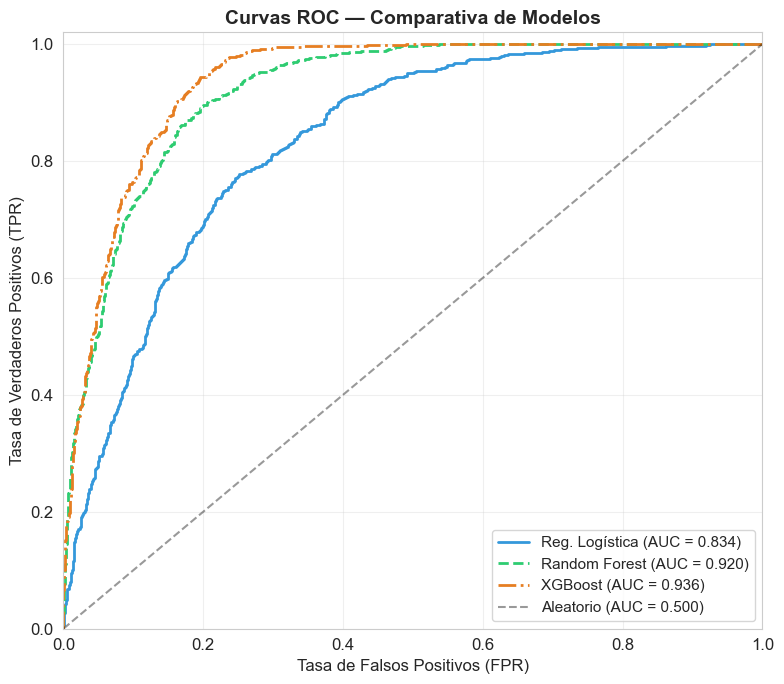

RESUMEN DE AUC
  AUC Reg. Logística        : 0.8339
  AUC Random Forest         : 0.9205
  AUC XGBoost               : 0.9361


In [19]:
# ============================================================
# 6.2 CURVAS ROC Y AUC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

for nombre, y_prob, color, ls in [
    ('Reg. Logística', y_prob_lr, '#3498db', '-'),
    ('Random Forest', y_prob_rf, '#2ecc71', '--'),
    ('XGBoost', y_prob_xgb, '#e67e22', '-.')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f'{nombre} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparativa de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen de AUC
print("=" * 40)
print("RESUMEN DE AUC")
print("=" * 40)
for nombre, y_prob in [('Reg. Logística', y_prob_lr),
                       ('Random Forest', y_prob_rf),
                       ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print(f"  AUC {nombre:<22s}: {auc(fpr, tpr):.4f}")

---
## 6. Feature Importance: ¿Qué Determina el Éxito?

Extraemos la importancia de cada variable en los modelos **Random Forest** y **XGBoost** para responder a la pregunta central del TFG:

> *¿Qué características hacen que un piso turístico en Madrid sea un caso de éxito económico?*

La importancia en Random Forest se basa en la reducción de impureza Gini, mientras que en XGBoost se basa en la ganancia (*gain*) promedio cuando una variable se usa para dividir los nodos del árbol.

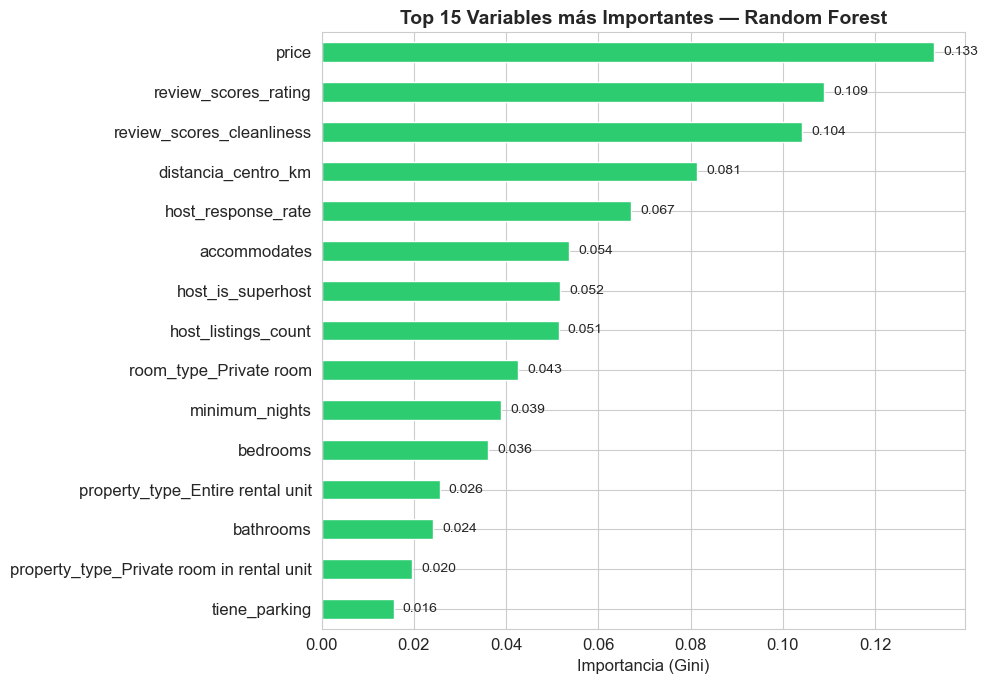


Top 15 Features — Random Forest:
   1. price                                    0.1328
   2. review_scores_rating                     0.1090
   3. review_scores_cleanliness                0.1042
   4. distancia_centro_km                      0.0814
   5. host_response_rate                       0.0671
   6. accommodates                             0.0537
   7. host_is_superhost                        0.0517
   8. host_listings_count                      0.0514
   9. room_type_Private room                   0.0426
  10. minimum_nights                           0.0390
  11. bedrooms                                 0.0361
  12. property_type_Entire rental unit         0.0256
  13. bathrooms                                0.0242
  14. property_type_Private room in rental unit 0.0196
  15. tiene_parking                            0.0156


In [20]:
# ============================================================
# 6.1 FEATURE IMPORTANCE — RANDOM FOREST
# ============================================================

fi_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15_rf = fi_rf.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15_rf.sort_values().plot.barh(ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Top 15 Variables más Importantes — Random Forest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
for i, (val, name) in enumerate(zip(top15_rf.sort_values(), top15_rf.sort_values().index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 15 Features — Random Forest:")
for i, (feat, imp) in enumerate(top15_rf.items(), 1):
    print(f"  {i:2d}. {feat:<40s} {imp:.4f}")

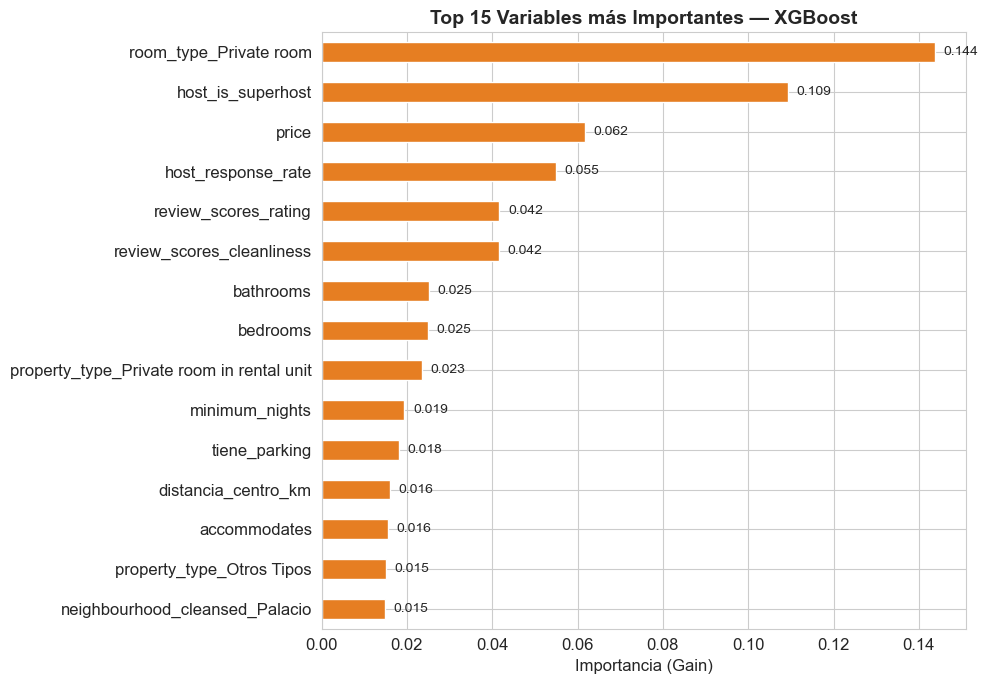


Top 15 Features — XGBoost:
   1. room_type_Private room                   0.1438
   2. host_is_superhost                        0.1093
   3. price                                    0.0618
   4. host_response_rate                       0.0548
   5. review_scores_rating                     0.0417
   6. review_scores_cleanliness                0.0415
   7. bathrooms                                0.0251
   8. bedrooms                                 0.0250
   9. property_type_Private room in rental unit 0.0235
  10. minimum_nights                           0.0194
  11. tiene_parking                            0.0180
  12. distancia_centro_km                      0.0160
  13. accommodates                             0.0156
  14. property_type_Otros Tipos                0.0151
  15. neighbourhood_cleansed_Palacio           0.0149


In [21]:
# ============================================================
# 6.2 FEATURE IMPORTANCE — XGBOOST
# ============================================================

fi_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
top15_xgb = fi_xgb.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15_xgb.sort_values().plot.barh(ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('Top 15 Variables más Importantes — XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Gain)')
for i, (val, name) in enumerate(zip(top15_xgb.sort_values(), top15_xgb.sort_values().index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 15 Features — XGBoost:")
for i, (feat, imp) in enumerate(top15_xgb.items(), 1):
    print(f"  {i:2d}. {feat:<40s} {imp:.4f}")

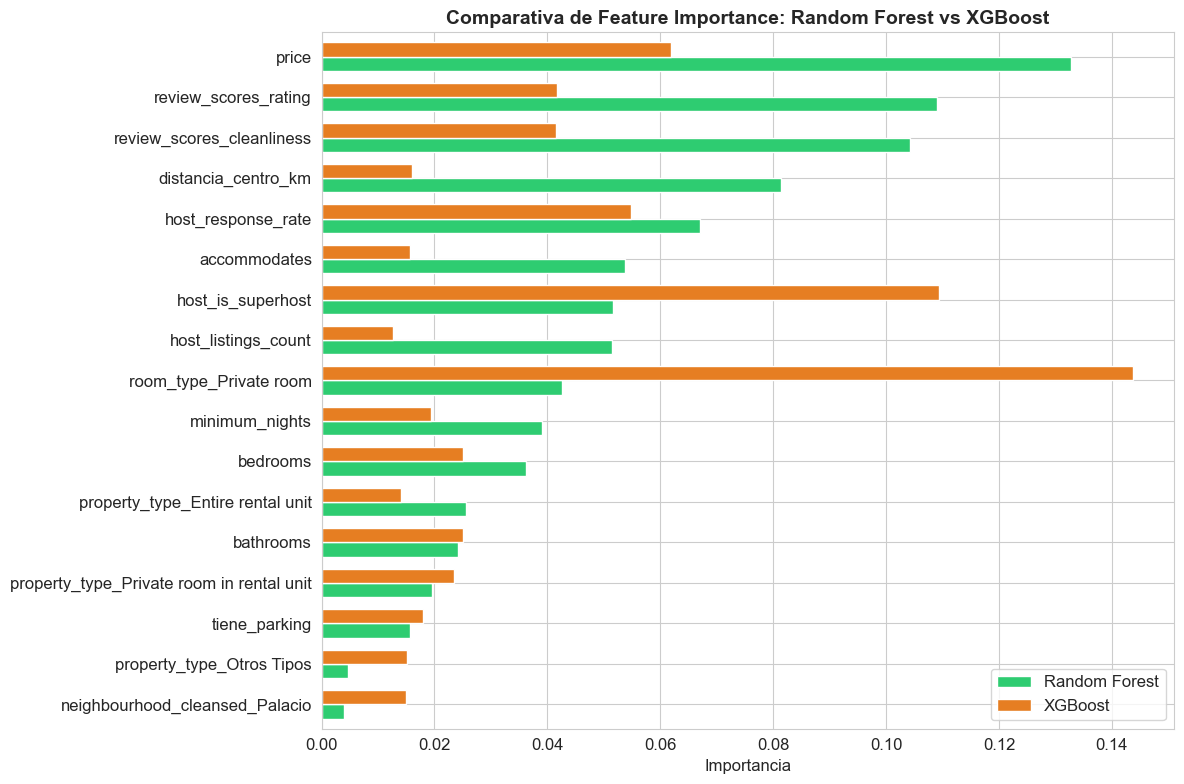

TOP 10 VARIABLES MÁS INFLUYENTES (consenso)
  1. price
  2. review_scores_rating
  3. review_scores_cleanliness
  4. host_is_superhost
  5. host_response_rate
  6. room_type_Private room
  7. distancia_centro_km
  8. accommodates
  9. bedrooms
  10. minimum_nights


In [22]:
# ============================================================
# 6.3 COMPARATIVA DE FEATURE IMPORTANCE (RF vs XGBoost)
# ============================================================

# Unimos el top 15 de ambos modelos
top_features = list(set(top15_rf.index) | set(top15_xgb.index))

df_fi = pd.DataFrame({
    'Random Forest': fi_rf[top_features],
    'XGBoost': fi_xgb[top_features]
}).sort_values('Random Forest', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
df_fi.plot.barh(ax=ax, color=['#2ecc71', '#e67e22'], edgecolor='white', width=0.7)
ax.set_title('Comparativa de Feature Importance: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Top 10 variables comunes (por ranking promedio)
print("=" * 50)
print("TOP 10 VARIABLES MÁS INFLUYENTES (consenso)")
print("=" * 50)
rank_rf = fi_rf.rank(ascending=False)
rank_xgb = fi_xgb.rank(ascending=False)
avg_rank = ((rank_rf + rank_xgb) / 2).sort_values()
for i, (feat, rank) in enumerate(avg_rank.head(10).items(), 1):
    print(f"  {i}. {feat}")

---
### 6.4 Interpretabilidad del Modelo con SHAP (SHapley Additive exPlanations)

La Feature Importance clásica nos dice **qué** variables importan, pero no **cómo** ni **en qué dirección** influyen. SHAP resuelve esto aplicando la teoría de juegos cooperativos (valores de Shapley) para descomponer cada predicción individual en la contribución exacta de cada variable.

- **SHAP Summary Plot (Enjambre):** Visión global — cada punto es una observación, el eje X muestra el impacto en la predicción (SHAP value) y el color indica si el valor original de la variable era alto (rojo) o bajo (azul).
- **SHAP Waterfall Plot (Cascada):** Visión individual — descompone la predicción de un piso concreto mostrando cuánto aporta cada variable a favor o en contra del éxito.

> **Nota:** El cálculo de SHAP values sobre el conjunto de test puede tardar varios minutos dependiendo del hardware.

POSICIÓN DE LA VARIABLE ESPACIAL
  distancia_centro_km: posición 6 de 79
  |SHAP| medio: 0.340793


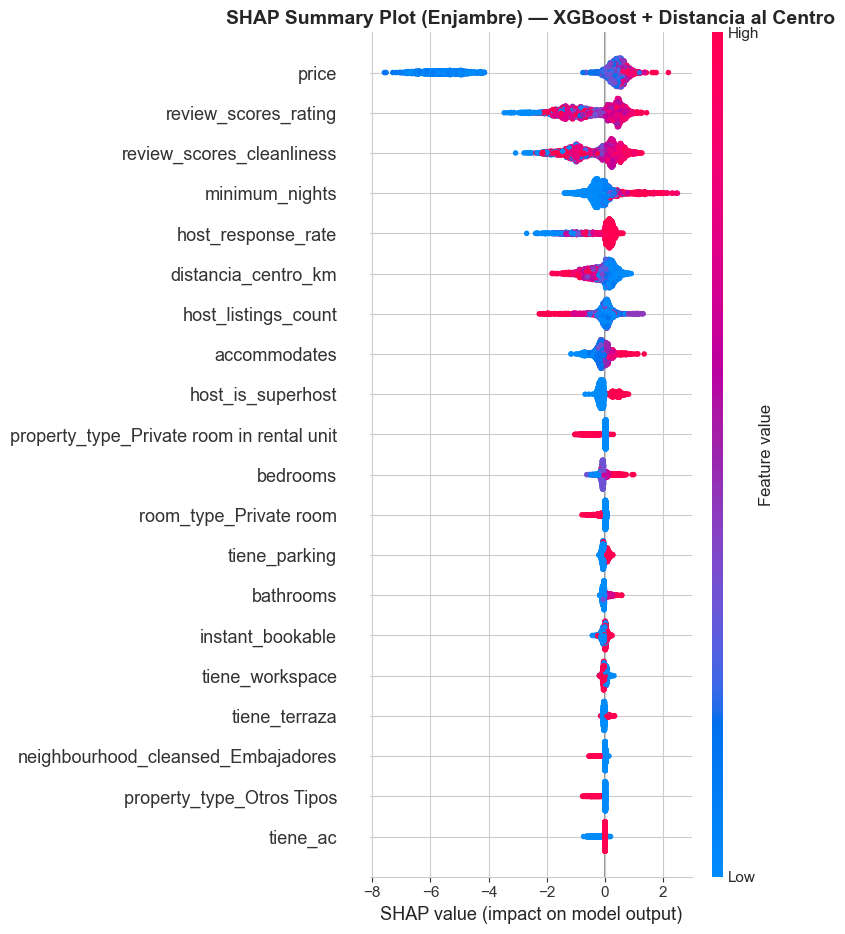

In [23]:
# ============================================================
# 6.4 INTERPRETABILIDAD CON SHAP
# ============================================================
# ⚠️ Este bloque puede tardar varios minutos en ejecutarse,
#    ya que calcula los valores SHAP para todas las observaciones
#    del conjunto de test usando el modelo XGBoost entrenado.
# ============================================================
import shap

# Explicador SHAP para modelos basados en árboles
explainer = shap.TreeExplainer(xgb)

# SHAP values del conjunto de test (se deja en variable shap_values para reutilización posterior)
shap_values = explainer(X_test)

# Matriz SHAP robusta para summary_plot y ranking
if hasattr(shap_values, 'values'):
    shap_values_matrix = shap_values.values
else:
    shap_values_matrix = shap_values

if isinstance(shap_values_matrix, list):
    shap_values_matrix = shap_values_matrix[1]

# ---------------------------------------------------------
# Ranking SHAP global para verificar posición de la variable espacial
# ---------------------------------------------------------
imp_shap = pd.Series(np.abs(shap_values_matrix).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

if 'distancia_centro_km' in imp_shap.index:
    pos_dist = int(imp_shap.index.get_loc('distancia_centro_km') + 1)
    print("=" * 60)
    print("POSICIÓN DE LA VARIABLE ESPACIAL")
    print("=" * 60)
    print(f"  distancia_centro_km: posición {pos_dist} de {len(imp_shap)}")
    print(f"  |SHAP| medio: {imp_shap['distancia_centro_km']:.6f}")
else:
    print("⚠️ 'distancia_centro_km' no aparece en X_test. Revisa la celda 5.1.")

# ---------------------------------------------------------
# GRÁFICO 1: SHAP Summary Plot (Enjambre)
# Visión GLOBAL: impacto de cada variable en todo el test set
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_matrix,
    X_test,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot (Enjambre) — XGBoost + Distancia al Centro',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




ANÁLISIS INDIVIDUAL — Observación #6 del Test Set
  Clase real:      Fracaso
  Predicción:      Fracaso
  Probabilidad:    5.62%


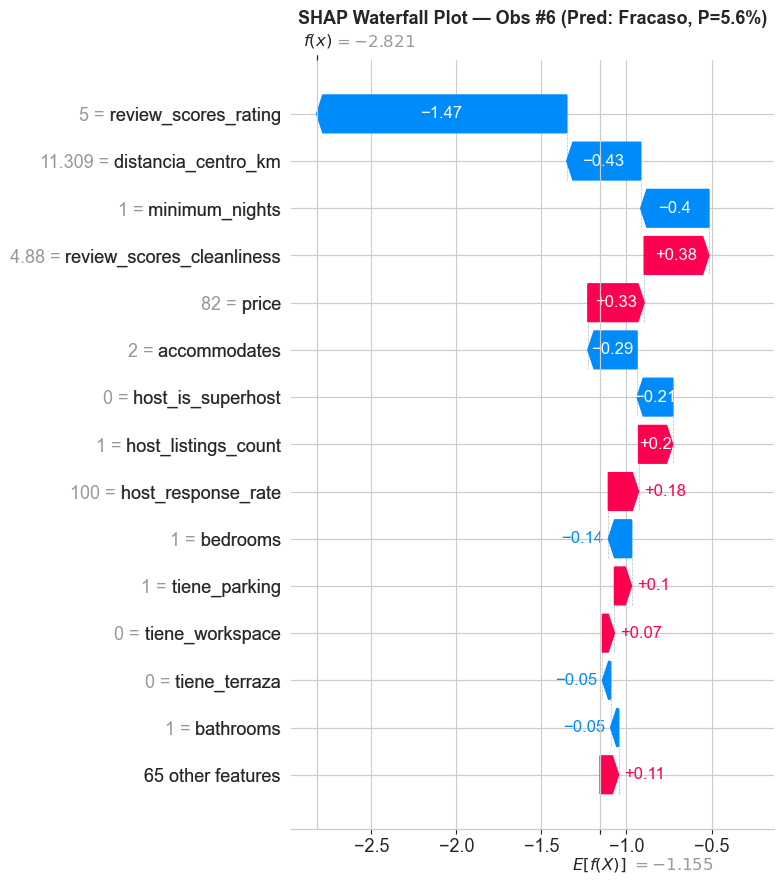

In [24]:
# ---------------------------------------------------------
# GRÁFICO 2: SHAP Waterfall Plot (Cascada)
# Visión INDIVIDUAL: descomposición de la predicción
# ---------------------------------------------------------
idx = 6
pred_clase = xgb.predict(X_test.iloc[[idx]])[0]
pred_prob = xgb.predict_proba(X_test.iloc[[idx]])[0][1]
real = y_test.iloc[idx]

print("\n" + "=" * 60)
print(f"ANÁLISIS INDIVIDUAL — Observación #{idx} del Test Set")
print("=" * 60)
print(f"  Clase real:      {'Éxito' if real == 1 else 'Fracaso'}")
print(f"  Predicción:      {'Éxito' if pred_clase == 1 else 'Fracaso'}")
print(f"  Probabilidad:    {pred_prob:.2%}")
print("=" * 60)

# Si SHAP devuelve Explanation, usamos la fila directa
if hasattr(shap_values, 'values'):
    shap_fila = shap_values[idx]
else:
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[1] if len(np.atleast_1d(base_value)) > 1 else float(np.atleast_1d(base_value)[0])

    shap_fila = shap.Explanation(
        values=shap_values_matrix[idx],
        base_values=base_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_fila, max_display=15, show=False)
plt.title(
    f'SHAP Waterfall Plot — Obs #{idx} (Pred: {"Éxito" if pred_clase else "Fracaso"}, P={pred_prob:.1%})',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [25]:
"""1. El filtro implacable del Superhost (Adiós al Clúster 1)Podría parecer que por tener pocos pisos (host_listings_count = 6), debería ir al Clúster 1
(El "Super-Anfitrión Boutique", que promedia 8.7 pisos). Sin embargo, la variable host_is_superhost en el Clúster 1 tiene una media exacta de 1.000 (el 100% lo son) . 
Al tener un 0 en Superhost, el algoritmo calcula una distancia matemática enorme y le cierra la puerta de la élite automáticamente. En cambio, el Clúster 2 tiene una media
de Superhost de 0.000, encajando como un guante con este anfitrión .2. Demasiado barato para el lujo, demasiado caro para el Low-CostCon un precio de 125€ y 4 plazas, no tiene 
el volumen financiero para entrar en el Clúster 0 (Las "Grandes Agencias"), cuya media es de 250€ y 6 plazas .Tampoco es el típico piso compartido de estudiantes.
Su precio lo aleja totalmente del Clúster 3 ("Low Cost"), que promedia 90€ por poco más de 2 plazas .Su encaje natural es el Clúster 2, el estándar del mercado, cuya media son 109€ y 2.8
plazas .3. El cajón de sastre de la mala gestiónComo bien defines en tu trabajo, el Clúster 2 es la gran masa del mercado (casi 7.500 pisos) que "no termina de despuntar" . 
Aunque la media de anuncios de este clúster está inflada por algunas agencias medianas (71 anuncios de media), su rasgo definitorio no es el tamaño, sino la falta de excelencia . 
Es el clúster con peores notas generales de los apartamentos enteros (4.57 de media). Este anfitrión, con su desastroso 4.07, se convierte de hecho en uno de los peores alumnos de
la clase media.💡 Cómo hilar esto en tu defensa oralPuedes usar este piso para explicar la diferencia entre los tres clústeres principales de pisos enteros. La narrativa sería:"Este
activo (Obs #666) pertenece al Clúster 2, que representa la gran bolsa de mediocridad del mercado madrileño. Si este mismo anfitrión cuidara la limpieza y dejara de aceptar reservas
de 1 sola noche, conseguiría la medalla de Superhost y sus valoraciones subirían, lo que matemáticamente lo propulsaría hacia el Clúster 1 (El Super-Anfitrión Boutique). Ese simple 
salto cualitativo transformaría un negocio que hoy tiene un 6.7% de probabilidad de éxito en uno altamente rentable, sin necesidad de cambiar ni el precio ni los muebles.

En el piso 667, da mucho peso a las valoraciones, siendo superhost, con 100% de respuestas y aun estando lejos guarda un gran precio competitivo para 4 personas y con garaje y donde premia
tener 18 pisos porque considera que es una gran gestora que piensa en el cliente"""


'1. El filtro implacable del Superhost (Adiós al Clúster 1)Podría parecer que por tener pocos pisos (host_listings_count = 6), debería ir al Clúster 1\n(El "Super-Anfitrión Boutique", que promedia 8.7 pisos). Sin embargo, la variable host_is_superhost en el Clúster 1 tiene una media exacta de 1.000 (el 100% lo son) . \nAl tener un 0 en Superhost, el algoritmo calcula una distancia matemática enorme y le cierra la puerta de la élite automáticamente. En cambio, el Clúster 2 tiene una media\nde Superhost de 0.000, encajando como un guante con este anfitrión .2. Demasiado barato para el lujo, demasiado caro para el Low-CostCon un precio de 125€ y 4 plazas, no tiene \nel volumen financiero para entrar en el Clúster 0 (Las "Grandes Agencias"), cuya media es de 250€ y 6 plazas .Tampoco es el típico piso compartido de estudiantes.\nSu precio lo aleja totalmente del Clúster 3 ("Low Cost"), que promedia 90€ por poco más de 2 plazas .Su encaje natural es el Clúster 2, el estándar del mercado, cuy

---
### 6.5 Gráficos de Interacción SHAP (Dependence Plots)

Los SHAP Dependence Plots van un paso más allá del Summary Plot: muestran **cómo interactúan dos variables** para influir en la predicción. Cada punto es una observación del test set:

- **Eje X:** Valor real de la variable principal.
- **Eje Y:** SHAP value (contribución a la predicción de éxito).
- **Color:** Valor de la variable de interacción, revelando efectos cruzados.

Analizamos dos interacciones clave para el inversor:

1. **Precio × Capacidad** — ¿La capacidad modula el impacto del precio? Un precio alto puede ser positivo si el piso aloja a muchos huéspedes (el coste por persona sigue siendo competitivo).
2. **Tamaño del gestor × Tipo de alojamiento** — ¿Las grandes agencias (alto `host_listings_count`) obtienen ventaja especialmente cuando gestionan pisos enteros?

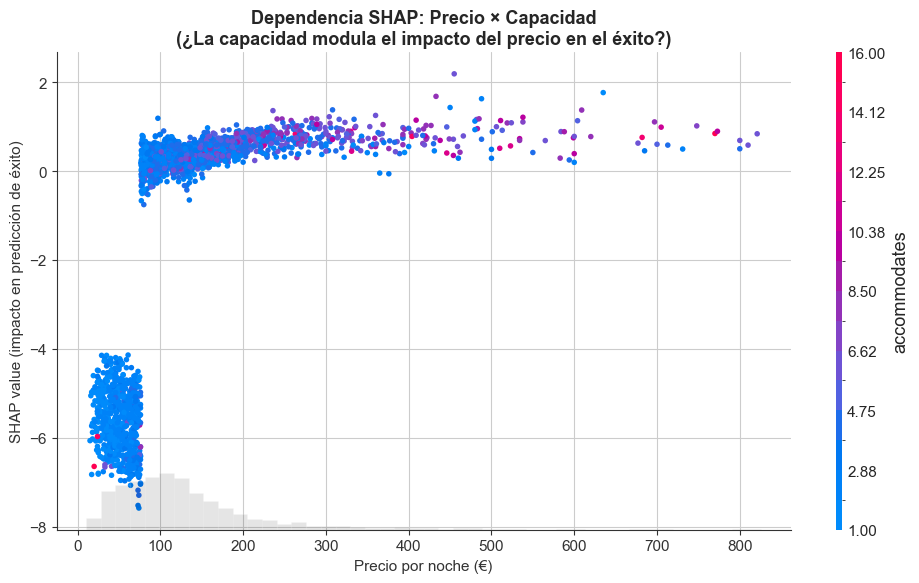

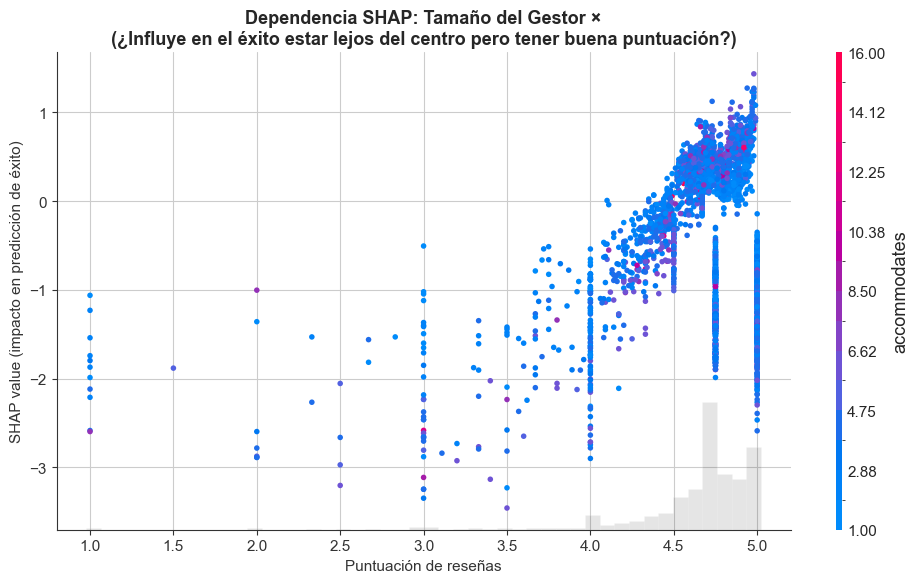

In [26]:
# ============================================================
# 6.5 GRÁFICOS DE INTERACCIÓN SHAP (DEPENDENCE PLOTS)
# ============================================================

# ---------------------------------------------------------
# GRÁFICO 3: Dependencia SHAP — Precio × Capacidad
# Pregunta: ¿Cómo modula la capacidad el efecto del precio?
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.scatter(
    shap_values[:, 'price'],
    color=shap_values[:, 'accommodates'],
    ax=ax, show=False
)
ax.set_title('Dependencia SHAP: Precio × Capacidad\n'
             '(¿La capacidad modula el impacto del precio en el éxito?)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Precio por noche (€)', fontsize=11)
ax.set_ylabel('SHAP value (impacto en predicción de éxito)', fontsize=11)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRÁFICO 4: Dependencia SHAP — Tamaño del gestor × Tipo
# Pregunta: ¿Las grandes agencias ganan más con pisos enteros?
# ---------------------------------------------------------
# Buscamos la columna dummy de room_type que exista en X_test
# (con drop_first=True, 'Entire home/apt' es la base eliminada;
#  las dummies son room_type_Private room, room_type_Shared room, etc.)


fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.scatter(
    shap_values[:, 'review_scores_rating'],  # Variable principal (eje X)
    color=shap_values[:, 'accommodates'],  # Variable de color (superhost o no)
    ax=ax, show=False
)
ax.set_title(f'Dependencia SHAP: Tamaño del Gestor ×\n'
             '(¿Influye en el éxito estar lejos del centro pero tener buena puntuación?)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Puntuación de reseñas', fontsize=11)
ax.set_ylabel('SHAP value (impacto en predicción de éxito)', fontsize=11)
plt.tight_layout()
plt.show()

---
### 6.6 Análisis Comparativo de Activos (SHAP Decision Plot)

El **Decision Plot** permite visualizar la *trayectoria predictiva* de una observación individual: partiendo de la base (valor esperado del modelo), cada variable empuja la predicción hacia arriba (éxito) o hacia abajo (fracaso).

Superponemos **dos casos extremos** encontrados automáticamente en el test set:
- El activo con la **mayor probabilidad de éxito** predicha por XGBoost.
- El activo con la **menor probabilidad de éxito**.

Al comparar ambas trayectorias, vemos exactamente **en qué variables divergen** los caminos de un piso exitoso y uno que fracasa.

CASOS EXTREMOS ENCONTRADOS EN EL TEST SET

  🏆 MEJOR ACTIVO (idx=1102):
     Probabilidad predicha de éxito: 98.63%
     Clase real: Éxito ✔

  📉 PEOR ACTIVO (idx=2296):
     Probabilidad predicha de éxito: 0.00%
     Clase real: Fracaso ✘


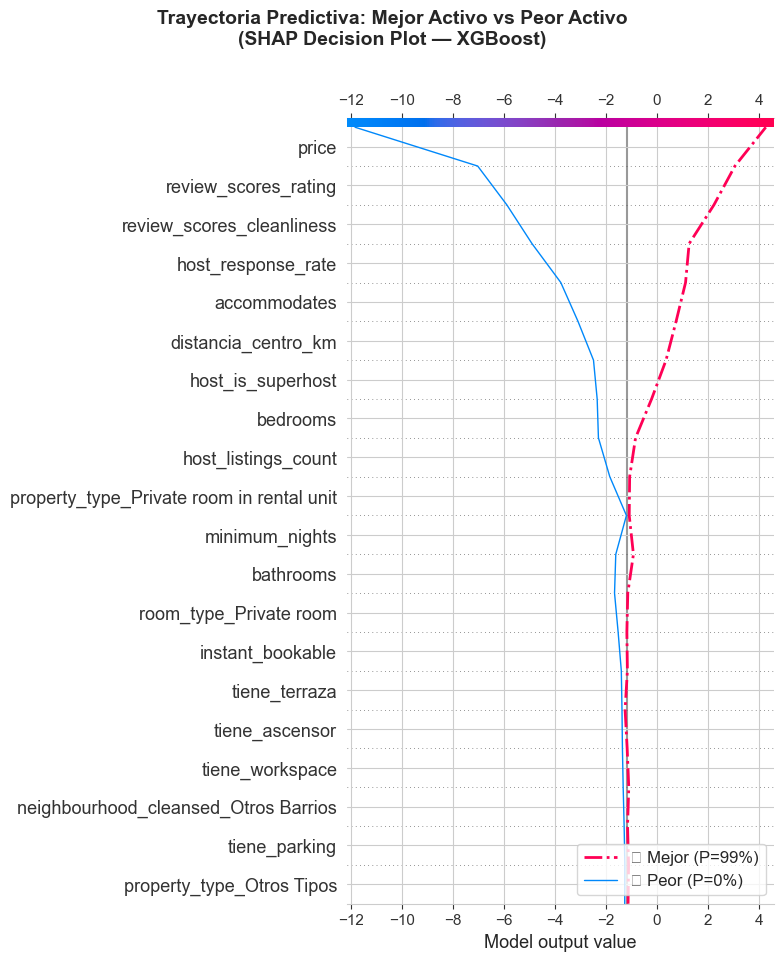


VARIABLES CON MAYOR DIVERGENCIA ENTRE AMBOS ACTIVOS
   1. price                                Mejor: +1.211 (↑ éxito)  |  Peor: -4.809 (↓ fracaso)
   2. review_scores_rating                 Mejor: +0.822 (↑ éxito)  |  Peor: -1.143 (↓ fracaso)
   3. review_scores_cleanliness            Mejor: +0.974 (↑ éxito)  |  Peor: -0.988 (↓ fracaso)
   4. host_response_rate                   Mejor: +0.140 (↑ éxito)  |  Peor: -1.127 (↓ fracaso)
   5. accommodates                         Mejor: +0.371 (↑ éxito)  |  Peor: -0.674 (↓ fracaso)
   6. distancia_centro_km                  Mejor: +0.396 (↑ éxito)  |  Peor: -0.608 (↓ fracaso)
   7. host_is_superhost                    Mejor: +0.566 (↑ éxito)  |  Peor: -0.144 (↓ fracaso)
   8. bedrooms                             Mejor: +0.628 (↑ éxito)  |  Peor: -0.049 (↓ fracaso)
   9. host_listings_count                  Mejor: +0.232 (↑ éxito)  |  Peor: -0.445 (↓ fracaso)
  10. property_type_Private room in rental unit  Mejor: +0.017 (↑ éxito)  |  Peor: 

In [27]:
# ============================================================
# 6.6 ANÁLISIS COMPARATIVO — SHAP DECISION PLOT
# ============================================================

# --- Paso 1: Buscar los dos casos extremos en el test set ---
# Obtenemos la probabilidad de éxito predicha para cada observación
probs_test = xgb.predict_proba(X_test)[:, 1]

# Índice del piso con MAYOR probabilidad de éxito (el "ganador")
idx_best = int(np.argmax(probs_test))
# Índice del piso con MENOR probabilidad de éxito (el "perdedor")
idx_worst = int(np.argmin(probs_test))

prob_best = probs_test[idx_best]
prob_worst = probs_test[idx_worst]
real_best = y_test.iloc[idx_best]
real_worst = y_test.iloc[idx_worst]

print("=" * 60)
print("CASOS EXTREMOS ENCONTRADOS EN EL TEST SET")
print("=" * 60)
print(f"\n  🏆 MEJOR ACTIVO (idx={idx_best}):")
print(f"     Probabilidad predicha de éxito: {prob_best:.2%}")
print(f"     Clase real: {'Éxito ✔' if real_best == 1 else 'Fracaso ✘'}")
print(f"\n  📉 PEOR ACTIVO (idx={idx_worst}):")
print(f"     Probabilidad predicha de éxito: {prob_worst:.2%}")
print(f"     Clase real: {'Éxito ✔' if real_worst == 1 else 'Fracaso ✘'}")

# --- Paso 2: Extraemos los SHAP values en formato matricial ---
# shap.decision_plot necesita el expected_value (base) y la matriz de SHAP values
expected_value = explainer.expected_value

# Extraemos los SHAP values como array numpy para las dos observaciones
shap_vals_matrix = shap_values.values[[idx_best, idx_worst], :]

# --- Paso 3: Decision Plot superpuesto ---
fig, ax = plt.subplots(figsize=(10, 10))
plt.suptitle('Trayectoria Predictiva: Mejor Activo vs Peor Activo\n'
             '(SHAP Decision Plot — XGBoost)',
             fontsize=14, fontweight='bold', y=1.01)

shap.decision_plot(
    expected_value,
    shap_vals_matrix,
    feature_names=X_test.columns.tolist(),
    highlight=[0],  # Resalta la primera trayectoria (el ganador)
    legend_labels=[
        f'🏆 Mejor (P={prob_best:.0%})',
        f'📉 Peor (P={prob_worst:.0%})'
    ],
    legend_location='lower right',
    show=False
)
plt.tight_layout()
plt.show()

# --- Paso 4: Resumen de las variables que más difieren ---
print("\n" + "=" * 60)
print("VARIABLES CON MAYOR DIVERGENCIA ENTRE AMBOS ACTIVOS")
print("=" * 60)
diff = np.abs(shap_vals_matrix[0] - shap_vals_matrix[1])
diff_series = pd.Series(diff, index=X_test.columns).sort_values(ascending=False)
for i, (feat, val) in enumerate(diff_series.head(10).items(), 1):
    shap_best = shap_vals_matrix[0, X_test.columns.get_loc(feat)]
    shap_worst = shap_vals_matrix[1, X_test.columns.get_loc(feat)]
    dir_best = '↑ éxito' if shap_best > 0 else '↓ fracaso'
    dir_worst = '↑ éxito' if shap_worst > 0 else '↓ fracaso'
    print(f"  {i:2d}. {feat:<35s}  Mejor: {shap_best:+.3f} ({dir_best})  |  "
          f"Peor: {shap_worst:+.3f} ({dir_worst})")

In [28]:
# ============================================================
# 7. SIMULACIÓN DE CASOS DE USO (EL VALOR PARA EL INVERSOR)
# ============================================================

# 1. Definimos las características del "Piso A" (Gestión Amateur)
# Un inversor que lo pone caro, tarda en responder y no tiene buenas reseñas.
datos_amateur = {
    'accommodates': 4,
    'bedrooms': 2,
    'bathrooms': 1,
    'price': 160,                    # Precio poco competitivo
    'minimum_nights': 3,
    'instant_bookable': 0,           # Obliga a los huéspedes a pedir permiso
    'host_is_superhost': 0,          # No es superhost
    'host_response_rate': 60,        # Contesta solo al 60% de los mensajes
    'host_listings_count': 1,        
    'review_scores_rating': 4.3,     # Nota "buena" para un humano, pésima para Airbnb
    'review_scores_cleanliness': 4.4
}

# 2. Definimos las características del "Piso B" (Gestión Profesional)
# El MISMO piso, pero bien gestionado.
datos_profesional = {
    'accommodates': 4,
    'bedrooms': 2,
    'bathrooms': 1,
    'price': 120,                    # Precio optimizado al mercado
    'minimum_nights': 3,
    'instant_bookable': 1,           # Reserva automática (facilita la venta)
    'host_is_superhost': 1,          # Tiene la medalla de Superhost
    'host_response_rate': 100,       # Contesta al 100% casi al instante
    'host_listings_count': 1,
    'review_scores_rating': 4.8,     # Reputación excelente
    'review_scores_cleanliness': 4.8,  # Limpieza impecable    
}

# Función mágica para hacer la predicción
def evaluar_piso(datos_piso, modelo, columnas_modelo):
    # Creamos una fila llena de ceros con la forma exacta que espera el algoritmo
    df_simulacion = pd.DataFrame(0, index=[0], columns=columnas_modelo)
    
    # Rellenamos los datos numéricos
    for col, val in datos_piso.items():
        if col in df_simulacion.columns:
            df_simulacion.at[0, col] = val
            
    # Le decimos que está en el barrio de Sol (como ejemplo)
    if 'neighbourhood_cleansed_Sol' in df_simulacion.columns:
        df_simulacion.at[0, 'neighbourhood_cleansed_Sol'] = 1
        
    # Le decimos que es un apartamento entero (si no marcamos 'Private room', asume que es la base)
    
    # Calculamos la probabilidad con XGBoost
    probabilidad = modelo.predict_proba(df_simulacion)[0][1]
    return probabilidad

# 3. Lanzamos las simulaciones contra tu modelo XGBoost (la variable 'xgb')
prob_amateur = evaluar_piso(datos_amateur, xgb, X.columns)
prob_profesional = evaluar_piso(datos_profesional, xgb, X.columns)

# 4. Imprimimos el veredicto
print("="*60)
print("🏢 SIMULACIÓN DE INVERSIÓN: EL IMPACTO DE LA GESTIÓN 🏢")
print("="*60)
print(f"Mismo piso (2 hab, 1 baño, 4 pax) situado en Sol.")
print("-" * 60)
print(f"❌ ESCENARIO A (Gestión Amateur):")
print(f"   Probabilidad de entrar en el Top 25% más rentable: {prob_amateur:.2%}\n")

print(f"✅ ESCENARIO B (Gestión Profesional):")

print(f"   Probabilidad de entrar en el Top 25% más rentable: {prob_profesional:.2%}")
print("="*60)

🏢 SIMULACIÓN DE INVERSIÓN: EL IMPACTO DE LA GESTIÓN 🏢
Mismo piso (2 hab, 1 baño, 4 pax) situado en Sol.
------------------------------------------------------------
❌ ESCENARIO A (Gestión Amateur):
   Probabilidad de entrar en el Top 25% más rentable: 17.25%

✅ ESCENARIO B (Gestión Profesional):
   Probabilidad de entrar en el Top 25% más rentable: 70.44%


---
## 7. Conclusiones de Negocio para un Inversor

A partir del análisis de **Feature Importance** de los modelos Random Forest y XGBoost, y del EDA realizado, se extraen las siguientes conclusiones orientadas a un **inversor inmobiliario** que quiera maximizar sus probabilidades de éxito en el mercado de alquiler turístico de Madrid:

### Hallazgos principales

1. **El precio es la variable dominante.** Establecer una tarifa competitiva es el factor más determinante del éxito. No se trata de cobrar más, sino de encontrar el *sweet spot* entre precio y ocupación. Un piso sobrevalorado no se alquila; uno infravalorado pierde rentabilidad.

2. **La capacidad del alojamiento importa.** Las variables `accommodates`, `bedrooms` y `bathrooms` aparecen consistentemente en el top de importancia. Los pisos de 2-3 dormitorios que acomodan familias o grupos tienen ventaja competitiva frente a los estudios.

3. **La ubicación sigue siendo clave.** Los barrios céntricos de Madrid (Sol, Embajadores, Universidad, Justicia) aparecen como variables influyentes, confirmando la regla de oro inmobiliaria: *location, location, location*.

4. **Las puntuaciones de calidad importan.** `review_scores_rating` y `review_scores_cleanliness` influyen en el éxito. Mantener altos estándares de limpieza y atención no es opcional.

5. **Los servicios marcan diferencia.** Amenities como aire acondicionado, terraza/balcón y un espacio de trabajo dedicado incrementan la probabilidad de éxito. Son inversiones con retorno directo.

6. **La profesionalización del host cuenta.** `host_is_superhost` y `host_response_rate` indican que los host profesionales con alta tasa de respuesta tienen ventajas significativas.

### Recomendación para el inversor

> Apostar por **pisos de 2-3 dormitorios en barrios céntricos**, con precios competitivos alineados con el mercado, equipados con AC y terraza, y gestionados con altos estándares de calidad (Superhost, respuesta rápida, limpieza impecable). La profesionalización de la gestión no es un lujo, sino un **requisito** para competir en el cuartil superior del mercado.

### Limitaciones del estudio

- El modelo utiliza un snapshot temporal de Inside Airbnb; la estacionalidad no está capturada.
- Se excluyen variables de demanda observada (number_of_reviews, reviews_per_month, ocupación) para evitar Data Leakage, lo que puede reducir el accuracy pero hace el modelo más útil para un inversor que planifica **antes** de publicar.
- La definición de éxito (P75 de ingresos) es una elección de diseño; otros umbrales producirían resultados distintos.

---
## 8. Sistema de Scoring y Manual del Inversor

Transformamos la probabilidad bruta del modelo XGBoost en un **Score de Inversión (0–100)** que cualquier inversor puede interpretar sin conocimientos de Machine Learning. El sistema sigue un semáforo de riesgo con tres niveles:

| Score | Semáforo | Veredicto | Acción recomendada |
|---|---|---|---|
| **75 – 100** | 🟢 Riesgo Bajo | Inversión Recomendada | Ejecutar la operación |
| **40 – 74** | 🟡 Riesgo Medio | Inversión Condicionada | Optimizar pricing / perfil Superhost |
| **0 – 39** | 🔴 Riesgo Alto | Descarte Directo | Buscar otro activo |

> La función `generar_informe_inversor` recibe un diccionario con las características del piso y devuelve un informe profesional de *Due Diligence* automatizado.

In [29]:
def generar_informe_inversor(datos_piso, modelo, X_dataframe):
    """
    Genera un informe de Due Diligence inmobiliaria creando un 'clon' 
    del mercado real y aplicando las reglas del inversor.
    """
    # 1. EL TRUCO DEFINITIVO: Copiamos la mediana exacta de todo tu mercado
    df_sim = pd.DataFrame([X_dataframe.median()])
    
    # 2. Limpieza de seguridad: Apagamos todos los barrios y tipos de propiedad
    # para evitar que el piso esté en dos sitios a la vez por culpa de la mediana
    for col in df_sim.columns:
        if 'neighbourhood_cleansed_' in col or 'room_type_' in col or 'property_type_' in col:
            df_sim.at[0, col] = 0
            
    # 3. Inyectamos las decisiones del inversor (tus datos)
    for col, val in datos_piso.items():
        if col in df_sim.columns:
            df_sim.at[0, col] = val
            
    # 4. Red de seguridad: Si no has puesto barrio o tipo, le asignamos los mejores por defecto
    barrio_ok = any(col.startswith('neighbourhood_cleansed_') and val == 1 for col, val in datos_piso.items())
    tipo_ok = any(col.startswith('room_type_') and val == 1 for col, val in datos_piso.items())
    
    if not barrio_ok and 'neighbourhood_cleansed_Centro' in df_sim.columns:
        df_sim.at[0, 'neighbourhood_cleansed_Centro'] = 1
    if not tipo_ok and 'room_type_Entire home/apt' in df_sim.columns:
        df_sim.at[0, 'room_type_Entire home/apt'] = 1

    # 5. Predicción con XGBoost
    probabilidad = modelo.predict_proba(df_sim)[0][1]
    score = int(probabilidad * 100)

    # 6. Interfaz del informe
    print("=" * 60)
    print("🏢 INFORME DE DUE DILIGENCE INMOBILIARIA (XGBoost)")
    print("=" * 60)
    print(f"\n📋 CARACTERÍSTICAS DEL ACTIVO ANALIZADO:")
    print("-" * 60)
    for key, val in datos_piso.items():
        # Filtramos para que no imprima cosas feas si no las pusiste
        if val == 1 and ('neighbourhood' in key or 'room_type' in key):
            print(f"  • {key.split('_')[-1]:<35s} → Sí")
        elif 'neighbourhood' not in key and 'room_type' not in key:
            print(f"  • {key:<35s} → {val}")

    print(f"\n{'=' * 60}")
    print(f"📊 SCORE PREDICTIVO: {score} / 100")
    print(f"   (Probabilidad de entrar en el Top 25%: {probabilidad:.2%})")
    print("-" * 60)

    if score >= 75:
        print("🟢 NIVEL DE RIESGO: BAJO (High Conviction)")
        print("-" * 60)
        print("Veredicto: INVERSIÓN RECOMENDADA.")
        print("El activo cumple con los estándares de la élite del mercado.")
        print("Alta probabilidad de maximizar el ROI.")
    elif score >= 40:
        print("🟡 NIVEL DE RIESGO: MEDIO (Value-Add)")
        print("-" * 60)
        print("Veredicto: INVERSIÓN CONDICIONADA.")
        print("El activo tiene potencial, pero requiere optimización operativa.")
        print("Recomendaciones: Ajustar precio, mejorar a Superhost o activar reservas inmediatas.")
    else:
        print("🔴 NIVEL DE RIESGO: ALTO")
        print("-" * 60)
        print("Veredicto: DESCARTE DIRECTO.")
        print("El modelo de negocio propuesto no alcanza el umbral de rentabilidad.")
        print("Recomendaciones: Bajar drásticamente el precio o cambiar a alquiler tradicional.")
    print("=" * 60)

# ============================================================
# DEMO: El piso perfecto (Debería dar un Score Verde)
# ============================================================
piso_prueba_ganador = {
    'accommodates': 4,
    'bedrooms': 2,
    'bathrooms': 1,
    'price': 300,                   # Precio sensato
    'minimum_nights': 2,
    'instant_bookable': 1,          # Gestión Pro
    'host_is_superhost': 1,         # Gestión Pro
    'host_response_rate': 100,      # Gestión Pro
    'host_listings_count': 3,       # Pequeña agencia/inversor
    'review_scores_rating': 4.9, 
    'review_scores_cleanliness': 4.9,  # Excelente reputación
    'room_type_Entire home/apt': 1, # Piso entero
    'neighbourhood_cleansed_Centro': 1 # En el Centro
}

# ¡OJO A ESTA LÍNEA! Le pasamos X (mayúscula), no X.columns
generar_informe_inversor(piso_prueba_ganador, xgb, X)

🏢 INFORME DE DUE DILIGENCE INMOBILIARIA (XGBoost)

📋 CARACTERÍSTICAS DEL ACTIVO ANALIZADO:
------------------------------------------------------------
  • accommodates                        → 4
  • bedrooms                            → 2
  • bathrooms                           → 1
  • price                               → 300
  • minimum_nights                      → 2
  • instant_bookable                    → 1
  • host_is_superhost                   → 1
  • host_response_rate                  → 100
  • host_listings_count                 → 3
  • review_scores_rating                → 4.9
  • review_scores_cleanliness           → 4.9
  • Entire home/apt                     → Sí
  • Centro                              → Sí

📊 SCORE PREDICTIVO: 84 / 100
   (Probabilidad de entrar en el Top 25%: 84.26%)
------------------------------------------------------------
🟢 NIVEL DE RIESGO: BAJO (High Conviction)
------------------------------------------------------------
Veredicto: INVERSIÓN R

In [30]:
"""Para entender las predicciones de XGBOOST, hay que mirar precio por huesped por barrio junto con precio por capacidad
para ver si el precio esta desorbitado para su localizacion o no. Luego, mirar cada tipo de cluster que nos ha salido para ver que tipo de piso 
es el estudiado y en que segmento del mercado está para comparar sus métricas medias. Por último, mirar el ranking de variables más importantes 
para ver que es lo que más pesa en la predicción de éxito y ver si el piso cumple con esas características o no y sobretodo entender porque 
el modelo ha pesado más unas variables que otras. (corroborar con evidencia empirica investigando)"""

'Para entender las predicciones de XGBOOST, hay que mirar precio por huesped por barrio junto con precio por capacidad\npara ver si el precio esta desorbitado para su localizacion o no. Luego, mirar cada tipo de cluster que nos ha salido para ver que tipo de piso \nes el estudiado y en que segmento del mercado está para comparar sus métricas medias. Por último, mirar el ranking de variables más importantes \npara ver que es lo que más pesa en la predicción de éxito y ver si el piso cumple con esas características o no y sobretodo entender porque \nel modelo ha pesado más unas variables que otras. (corroborar con evidencia empirica investigando)'